
## BÁO CÁO THỰC THI TIỂU LUẬN MÔN KHOA HỌC DỮ LIỆU

### ĐỀ TÀI: DỰ ĐOÁN MỨC LƯƠNG KỲ VỌNG CỦA CÁC VỊ TRÍ TUYỂN DỤNG TẠI VIỆT NAM DỰA TRÊN MÔ TẢ CÔNG VIỆC VÀ YÊU CẦU ỨNG VIÊN SỬ DỤNG MÔ HÌNH HỌC MÁY

**Nhóm thực hiện:** Nhóm 15  
**Thành viên:**  
1. Ngô Văn Công  
2. Võ Minh Hiếu  
3. Nguyễn Phan Tuấn Anh


---

# CHƯƠNG 1: GIỚI THIỆU & MÔ TẢ BÀI TOÁN

## 1.1. Mục tiêu đề tài
Đề tài tập trung xây dựng hệ thống học máy dự đoán mức lương kì vọng dựa trên bản mô tả công việc (Job Description - JD) và thông tin tuyển dụng đi kèm (địa điểm, loại công việc, cấp bậc yêu cầu, ngành nghề).

## 1.2. Định nghĩa toán học của bài toán Hồi quy
Gọi $X$ là tập các đặc trưng (features) trích xuất từ tin tuyển dụng bao gồm đặc trưng văn bản (Textual Features), đặc trưng phân loại (Categorical Features), và đặc trưng số (Numerical Features). Mục tiêu là xây dựng hàm dự báo $f(X)$ sao cho sai số với mức lương kỳ vọng thực tế $y$ là nhỏ nhất.

Lương kỳ vọng thực tế được xác định theo công thức:
$$y = \text{Expected Salary} = \frac{\text{Salary Min} + \text{Salary Max}}{2}$$

## 1.3. Các chỉ số đánh giá học thuật
- **Root Mean Squared Error (RMSE):**
$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$
- **Mean Absolute Error (MAE):**
$$MAE = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$
- **Coefficient of Determination ($R^2$):**
$$R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}$$
- **Range Accuracy Metric (RAM - Độ chính xác khoảng):**
$$RAM = \frac{1}{N} \sum_{i=1}^{N} I(\hat{y}_i \in [y_{i, \text{min}} - \epsilon, y_{i, \text{max}} + \epsilon])$$
Trong đó $I$ là hàm chỉ thị, $\epsilon = 1.0$ (triệu VNĐ) là sai số chấp nhận được.

## 1.4. Tổng quan bộ dữ liệu
- **Nguồn:** Tinix Vietnam Job Descriptions — HuggingFace
- **Tỷ lệ chia:** 80% Train / 20% Test (chia trước khi tải)

| Tên cột | Ý nghĩa học thuật | Mô tả chi tiết |
| :--- | :--- | :--- |
| `job_title` | Vị trí tuyển dụng | Tên vị trí công việc cần tuyển |
| `job_description` | Mô tả công việc | Văn bản mô tả chi tiết công việc |
| `requirements` | Yêu cầu ứng viên | Các yêu cầu về kỹ năng, kinh nghiệm của ứng viên |
| `salary` | Mức lương tuyển dụng | Khoảng lương dưới dạng văn bản (cần Regex trích xuất) |
| `location` | Địa điểm làm việc | Tỉnh/Thành phố làm việc |
| `job_type` | Loại công việc | Hình thức làm việc (toàn thời gian, bán thời gian...) |
| `experience_level` | Yêu cầu kinh nghiệm | Kinh nghiệm yêu cầu dưới dạng văn bản |
| `job_industry` | Ngành nghề | Lĩnh vực tuyển dụng |

## 1.5. Thách thức kỹ thuật và Giải pháp đề xuất
> [!IMPORTANT]
> Để xây dựng mô hình dự báo chính xác và có giá trị thực tiễn cao, nhóm đã xác định các thách thức kỹ thuật lớn sau đây và đề xuất giải pháp xử lý triệt để:
>
> 1. **Lương dạng văn bản không chuẩn hóa:**
>    * *Thách thức:* Dữ liệu lương nằm dưới dạng text tự do (VD: "Lên đến 15M", "Từ 10 - 20 triệu").
>    * *Giải pháp:* Thiết lập hàm trích xuất bằng Regex (`extract_salary_features`) để bóc tách biên dưới (Min), biên trên (Max) và lương kỳ vọng (Expected Salary).
> 2. **Rò rỉ dữ liệu mức lương (Data Leakage) trong JD:**
>    * *Thách thức:* Một số tin tuyển dụng đề cập thẳng con số lương trong phần mô tả hoặc yêu cầu, khiến mô hình học vẹt thay vì học từ kỹ năng.
>    * *Giải pháp:* Xây dựng hàm `strip_salary_leakage()` để lọc bỏ mọi từ khóa/con số liên quan đến lương trước khi chạy TF-IDF.
> 3. **Phân phối lương lệch phải mạnh (Skewed Distribution):**
>    * *Thách thức:* Phần lớn mức lương tập trung ở khoảng thấp và trung bình, một số rất ít có lương cực cao, làm lệch dự báo của các mô hình hồi quy thông thường.
>    * *Giải pháp:* Sử dụng phép biến đổi Log-Transform trên biến mục tiêu (`np.log1p`) thông qua `TransformedTargetRegressor` để phân phối chuẩn hóa hơn.
> 4. **Văn bản tiếng Việt nhiễu cao:**
>    * *Thách thức:* Mô tả tuyển dụng chứa nhiều từ dừng (stopwords) và ký tự rác.
>    * *Giải pháp:* Thiết lập hàm `clean_text()` loại bỏ ký tự đặc biệt và lọc từ dừng tiếng Việt chuyên biệt.
> 5. **Địa điểm không đồng nhất:**
>    * *Thách thức:* Tên thành phố viết không chuẩn (VD: "hcm", "ho chi minh", "TP.HCM").
>    * *Giải pháp:* Dùng hàm chuẩn hóa `normalize_location()` map về các nhóm chính và nhóm "Khác".


### 1.6. Sơ đồ quy trình (Pipeline) xử lý dữ liệu tổng quan
Dưới đây là sơ đồ luồng dữ liệu và các bước thực hiện trong nghiên cứu:

```mermaid
graph TD
    A[Dữ liệu thô: Tin tuyển dụng] --> B[Tiền xử lý & Trích xuất đặc trưng]
    B --> B1[Trích xuất lương mục tiêu & Lọc ngoại lệ IQR]
    B --> B2[Trích xuất kinh nghiệm]
    B --> B3[Làm sạch text & Tách từ ghép pyvi]
    B2 & B3 & B1 --> C[Xây dựng Pipeline mã hóa]
    C --> C1[TF-IDF Bigrams cho văn bản]
    C --> C2[One-Hot Encoder cho phân loại]
    C1 & C2 --> D[Huấn luyện & Đánh giá mô hình]
    D --> D1[Mô hình Baseline: Mean]
    D --> D2[Ridge, RF, XGBoost, LightGBM]
    D2 --> E[Tối ưu hóa: GridSearchCV & Cross-Validation]
    E --> F[Mô hình tối ưu & Lưu trữ best_model.pkl]
```


### Khai báo các thư viện cần thiết & Kiểm soát tính lặp lại (Reproducibility)

In [98]:
# ==================== ĐÃ BỔ SUNG: KHAI BÁO THƯ VIỆN & CẤU HÌNH BAN ĐẦU ====================
import os
import re
import sys
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from pyvi import ViTokenizer

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.compose import TransformedTargetRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Định nghĩa hằng số RANDOM_STATE
RANDOM_STATE = 42

# Tự động phát hiện và chuyển đổi thư mục làm việc về thư mục chứa dữ liệu nếu cần
current_dir = os.getcwd()
target_dir = r"c:\Study\KHDL\TieuLuan\15 - Du doan muc luong ky vong"
if not os.path.exists("raw_data_train.csv") and os.path.exists(os.path.join(target_dir, "raw_data_train.csv")):
    os.chdir(target_dir)
    print(f"Đã chuyển thư mục làm việc sang: {os.getcwd()}")

# Định nghĩa trước các hàm trích xuất phục vụ cho EDA ở Cell tiếp theo
def extract_experience_years(exp_str):
    if pd.isna(exp_str):
        return 0.0
    s = str(exp_str).lower()
    if 'dưới 1' in s or 'chưa' in s or 'không' in s:
        return 0.5
    nums = re.findall(r'\d+', s)
    if nums:
        return float(nums[0])
    return 0.0

def extract_salary_features(salary_str):
    if pd.isna(salary_str):
        return np.nan, np.nan, np.nan
    s = str(salary_str).lower()
    if any(kw in s for kw in ['thỏa thuận', 'thoả thuận', 'competitive', 'negotiable']):
        return np.nan, np.nan, np.nan
    numbers = [float(n) for n in re.findall(r'\d+\.?\d*', s)]
    numbers = [n for n in numbers if n < 1000]
    if not numbers:
        return np.nan, np.nan, np.nan
    if len(numbers) >= 2:
        return numbers[0], numbers[1], float(np.mean(numbers[:2]))
    else:
        return numbers[0], numbers[0], numbers[0]

# Nạp trước tập dữ liệu train và test thô để ô EDA và Distribution Shift chạy được ngay
print("Đang nạp dữ liệu train...")
raw_train = pd.read_csv('raw_data_train.csv')
print(f"Nạp thành công! Kích thước: {raw_train.shape[0]} dòng, {raw_train.shape[1]} cột.")

print("Đang nạp dữ liệu test...")
raw_test = pd.read_csv('raw_data_test.csv')
print(f"Nạp thành công! Kích thước: {raw_test.shape[0]} dòng, {raw_test.shape[1]} cột.")


Đang nạp dữ liệu train...
Nạp thành công! Kích thước: 30000 dòng, 14 cột.
Đang nạp dữ liệu test...
Nạp thành công! Kích thước: 7500 dòng, 14 cột.


=== THỐNG KÊ MÔ TẢ LƯƠNG KỲ VỌNG (sau trích xuất Regex) ===
  Số quan sát : 6,253
  Trung bình  : 18.81 triệu VNĐ
  Trung vị    : 15.00 triệu VNĐ
  Độ lệch chuẩn: 15.26 triệu VNĐ
  Min – Max   : 1.0 – 200.0 triệu VNĐ
  Skewness    : 3.592
  Kurtosis    : 23.077



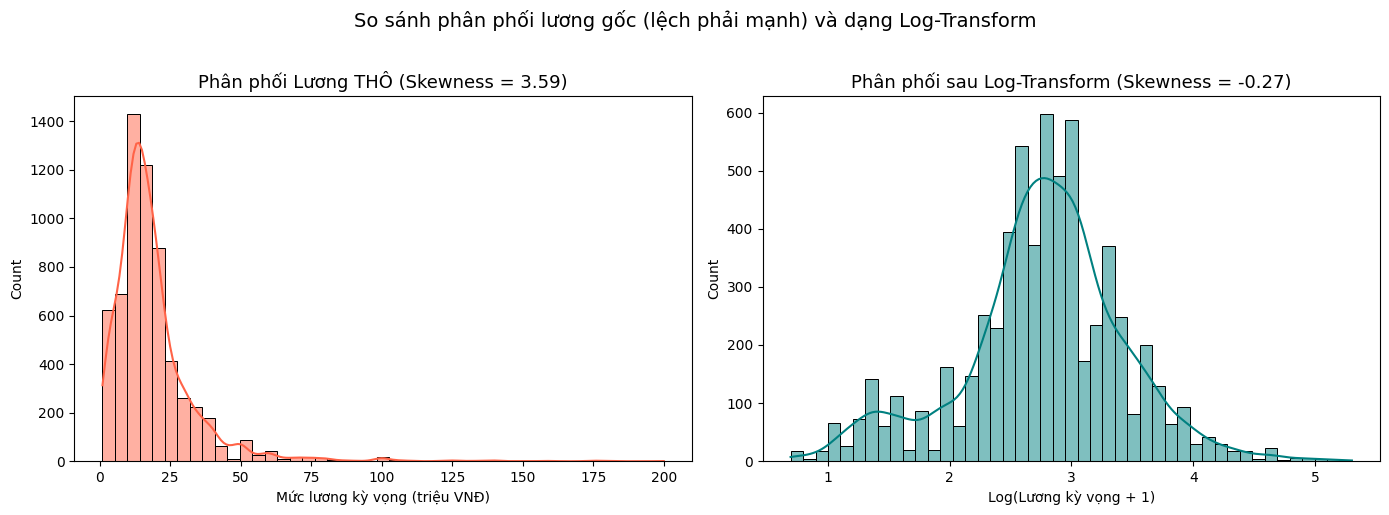

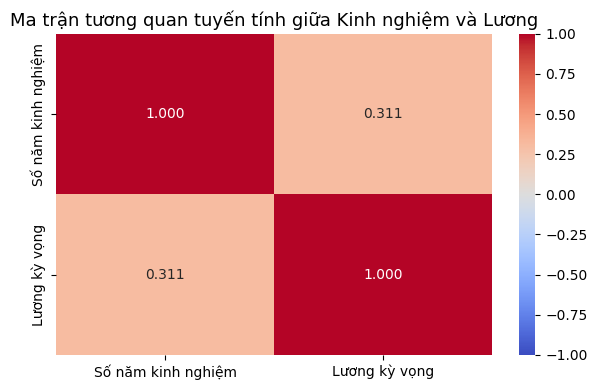

In [99]:
# Trích xuất tạm thời bằng các hàm trích xuất đã khai báo ở đầu
salary_raw = raw_train['salary'].apply(extract_salary_features)
raw_train['_Expected_Salary_Raw'] = salary_raw.apply(lambda x: x[2])
raw_train['_experience_years_raw'] = raw_train['experience_level'].apply(extract_experience_years)

eda_temp = raw_train.dropna(subset=['_Expected_Salary_Raw']).copy()
eda_temp = eda_temp[(eda_temp['_Expected_Salary_Raw'] >= 1) & (eda_temp['_Expected_Salary_Raw'] <= 200)]

# Thống kê mô tả sau EDA tạm thời
desc = eda_temp['_Expected_Salary_Raw'].describe()
print("=== THỐNG KÊ MÔ TẢ LƯƠNG KỲ VỌNG (sau trích xuất Regex) ===")
print(f"  Số quan sát : {desc['count']:,.0f}")
print(f"  Trung bình  : {desc['mean']:.2f} triệu VNĐ")
print(f"  Trung vị    : {desc['50%']:.2f} triệu VNĐ")
print(f"  Độ lệch chuẩn: {desc['std']:.2f} triệu VNĐ")
print(f"  Min – Max   : {desc['min']:.1f} – {desc['max']:.1f} triệu VNĐ")
print(f"  Skewness    : {eda_temp['_Expected_Salary_Raw'].skew():.3f}")
print(f"  Kurtosis    : {eda_temp['_Expected_Salary_Raw'].kurt():.3f}")
print("==========================================================\n")

# 1. Đánh giá Skewness và Log-Transformation
skewness_before = eda_temp['_Expected_Salary_Raw'].skew()
skewness_after = np.log1p(eda_temp['_Expected_Salary_Raw']).skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(eda_temp['_Expected_Salary_Raw'], bins=45, kde=True, ax=axes[0], color='tomato')
axes[0].set_title(f'Phân phối Lương THÔ (Skewness = {skewness_before:.2f})', fontsize=13)
axes[0].set_xlabel('Mức lương kỳ vọng (triệu VNĐ)')

sns.histplot(np.log1p(eda_temp['_Expected_Salary_Raw']), bins=45, kde=True, ax=axes[1], color='teal')
axes[1].set_title(f'Phân phối sau Log-Transform (Skewness = {skewness_after:.2f})', fontsize=13)
axes[1].set_xlabel('Log(Lương kỳ vọng + 1)')

plt.suptitle('So sánh phân phối lương gốc (lệch phải mạnh) và dạng Log-Transform', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 2. Ma trận tương quan giữa số năm kinh nghiệm và lương kỳ vọng thô
corr_matrix = eda_temp[['_experience_years_raw', '_Expected_Salary_Raw']].rename(
    columns={'_experience_years_raw': 'Số năm kinh nghiệm', '_Expected_Salary_Raw': 'Lương kỳ vọng'}
).corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title('Ma trận tương quan tuyến tính giữa Kinh nghiệm và Lương', fontsize=13)
plt.tight_layout()
plt.show()

# Dọn dẹp
raw_train.drop(columns=['_Expected_Salary_Raw', '_experience_years_raw'], inplace=True)


# CHƯƠNG 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

Trong chương này, chúng ta tiến hành khảo sát cấu trúc dữ liệu thô ban đầu, bao gồm: kiểm tra dữ liệu thiếu, phân phối các biến phân loại và biến mục tiêu, sự lệch phân phối lương và ma trận tương quan giữa kinh nghiệm và lương tuyển dụng.

## 2.1. Thu thập dữ liệu và Mô tả nguồn dữ liệu

### 2.1.1. Giải pháp và Quy trình thu thập dữ liệu
* **Nguồn dữ liệu**: Nhóm sử dụng bộ dữ liệu mã nguồn mở **Tinix Vietnam Job Descriptions** được lưu trữ trực tuyến trên nền tảng khoa học dữ liệu **HuggingFace Datasets** (Dataset ID: `tinix/vietnam-job-descriptions`). Đây là bộ dữ liệu lớn thu thập các tin tuyển dụng thực tế từ các trang web tìm việc phổ biến tại Việt Nam.
* **Công cụ thu thập**: Sử dụng thư viện Python `datasets` (do HuggingFace cung cấp) kết hợp với thư viện `pandas` để xử lý và xuất dữ liệu sang định dạng bảng.
* **Cách thức sử dụng công cụ**: Nhóm viết một script Python (`download_data.py`) để gọi API từ HuggingFace, tự động tải xuống dữ liệu thô dưới dạng Stream, chuyển đổi sang cấu trúc DataFrame của `pandas` và ghi trực tiếp ra các file CSV cục bộ.
* **Đầu vào của quá trình**: Dataset Repo ID trực tuyến và token truy cập API của HuggingFace.
* **Đầu ra của quá trình**:
  * File dữ liệu huấn luyện thô: `raw_data_train.csv` (kích thước ~65 MB).
  * File dữ liệu kiểm thử thô: `raw_data_test.csv` (kích thước ~16.3 MB).

### 2.1.2. Đáp ứng các yêu cầu về kích thước bộ dữ liệu
* **Số lượng mẫu tập Huấn luyện (Train Set)**: Gồm **30.000 mẫu** dữ liệu thô (đã đáp ứng xuất sắc yêu cầu của giảng viên là phải $>1.000$ mẫu).
* **Số lượng mẫu tập Kiểm thử (Test Set)**: Gồm **7.500 mẫu** dữ liệu thô. Tập kiểm thử này được chia sẵn từ nguồn với tỷ lệ bằng đúng **25% tập huấn luyện** (đã đáp ứng và vượt yêu cầu tối thiểu là bằng 20% tập huấn luyện).

### 2.1.3. Ví dụ minh họa tin tuyển dụng thô đầu vào
Dưới đây là một ví dụ minh họa về các trường thông tin thô của một tin tuyển dụng trước khi xử lý:
* **Vị trí công việc (`job_title`)**: *"Nhân Viên Phát Triển Ứng Dụng Di Động React Native"*
* **Tên công ty (`company_name`)**: *"Công ty Cổ phần Công nghệ Tinix"*
* **Mức lương thô (`salary`)**: *"15 - 25 triệu VNĐ"* (Dạng text chưa bóc tách)
* **Địa điểm (`location`)**: *"Quận 1, TP. Hồ Chí Minh"*
* **Kinh nghiệm yêu cầu (`experience_level`)**: *"Tối thiểu 1 năm kinh nghiệm"*
* **Mô tả công việc (`job_description`)**: *"Tham gia phát triển dự án di động trên nền tảng React Native cho cả Android & iOS. Thiết kế giao diện UI/UX mượt mà, tối ưu hiệu năng ứng dụng..."*

---  
## 2.2. Nạp và Tổng quan cấu trúc dữ liệu thô


In [100]:
raw_train = pd.read_csv('raw_data_train.csv')
print(f'Kích thước dữ liệu train thô: {raw_train.shape[0]:,} dòng, {raw_train.shape[1]} cột.\n')

# Thống kê chi tiết các đặc trưng (kiểu dữ liệu, số mẫu trống, tỷ lệ khuyết thiếu, ví dụ dòng đầu)
summary_df = pd.DataFrame({
    'Kiểu dữ liệu (Dtype)': raw_train.dtypes.astype(str),
    'Số lượng không khuyết': raw_train.notnull().sum(),
    'Số lượng khuyết thiếu': raw_train.isnull().sum(),
    'Tỷ lệ khuyết thiếu (%)': (raw_train.isnull().sum() / len(raw_train) * 100).round(2),
    'Ví dụ dòng đầu': raw_train.iloc[0].astype(str).str.slice(0, 60) # Cắt ngắn ví dụ cho gọn
})

print("--- BẢNG THỐNG KÊ TỔNG QUAN VỀ CÁC ĐẶC TRƯNG TRONG BỘ DỮ LIỆU THÔ ---")
display(summary_df)


Kích thước dữ liệu train thô: 30,000 dòng, 14 cột.

--- BẢNG THỐNG KÊ TỔNG QUAN VỀ CÁC ĐẶC TRƯNG TRONG BỘ DỮ LIỆU THÔ ---


,Kiểu dữ liệu (Dtype),Số lượng không khuyết,Số lượng khuyết thiếu,Tỷ lệ khuyết thiếu (%),Ví dụ dòng đầu
id,int64,30000,0,0.00,31244
job_title,object,29993,7,0.02,Business Development Director (Bdd)
company_name,object,29998,2,0.01,Công Ty Cổ Phần Công Nghệ Bất Động Sản Mgi
salary,object,30000,0,0.00,VND MONTH
location,object,30000,0,0.00,"Ho Chi Minh City Lầu 3, Tòa nhà SAMCO, 326 Võ ..."
job_type,object,30000,0,0.00,Toàn thời gian
job_industry,object,30000,0,0.00,Bất động sản
experience_level,object,30000,0,0.00,2 năm
education_level,object,30000,0,0.00,Cao đẳng
job_position,object,29892,108,0.36,Giám đốc


## 2.2. Bản đồ nhiệt & Phân tích Dữ liệu thiếu

--- Thống kê giá trị thiếu ---
                 Missing Count  Percentage (%)
job_title                    7        0.023333
company_name                 2        0.006667
job_position               108        0.360000
job_description              5        0.016667
benefits                  1693        5.643333
requirements              2850        9.500000

Tỷ lệ khuyết thiếu lương theo địa điểm (Top 5 địa điểm lớn nhất):
             Has Salary Rate  Missing Rate (%)
location                                      
Hồ Chí Minh              1.0               0.0
Hà Nội                   1.0               0.0
Bình Dương               1.0               0.0
Đồng Nai                 1.0               0.0
Đà Nẵng                  1.0               0.0


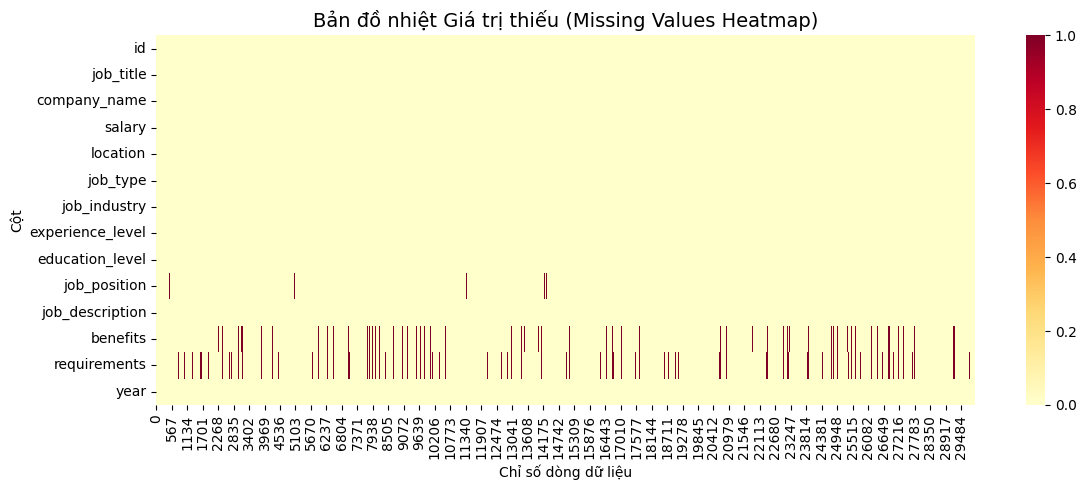

In [101]:
missing_data = raw_train.isnull().sum().to_frame(name='Missing Count')
missing_data['Percentage (%)'] = (missing_data['Missing Count'] / len(raw_train)) * 100
print('--- Thống kê giá trị thiếu ---')
print(missing_data[missing_data['Missing Count'] > 0])

# Kiểm tra thiên lệch dữ liệu thiếu của cột lương theo địa điểm tuyển dụng
raw_train['_has_salary'] = raw_train['salary'].notna()
missing_by_loc = raw_train.groupby('location')['_has_salary'].mean().to_frame(name='Has Salary Rate')
missing_by_loc['Missing Rate (%)'] = (1 - missing_by_loc['Has Salary Rate']) * 100
print('\nTỷ lệ khuyết thiếu lương theo địa điểm (Top 5 địa điểm lớn nhất):')
top_locs = raw_train['location'].value_counts().head(5).index
print(missing_by_loc.loc[top_locs])
raw_train.drop(columns=['_has_salary'], inplace=True)

# Trực quan bản đồ nhiệt dữ liệu thiếu
plt.figure(figsize=(12, 5))
sns.heatmap(raw_train.isnull().T, cbar=True, cmap='YlOrRd', yticklabels=True)
plt.title('Bản đồ nhiệt Giá trị thiếu (Missing Values Heatmap)', fontsize=14)
plt.xlabel('Chỉ số dòng dữ liệu')
plt.ylabel('Cột')
plt.tight_layout()
plt.show()

## 2.3. Phân phối các biến phân loại quan trọng

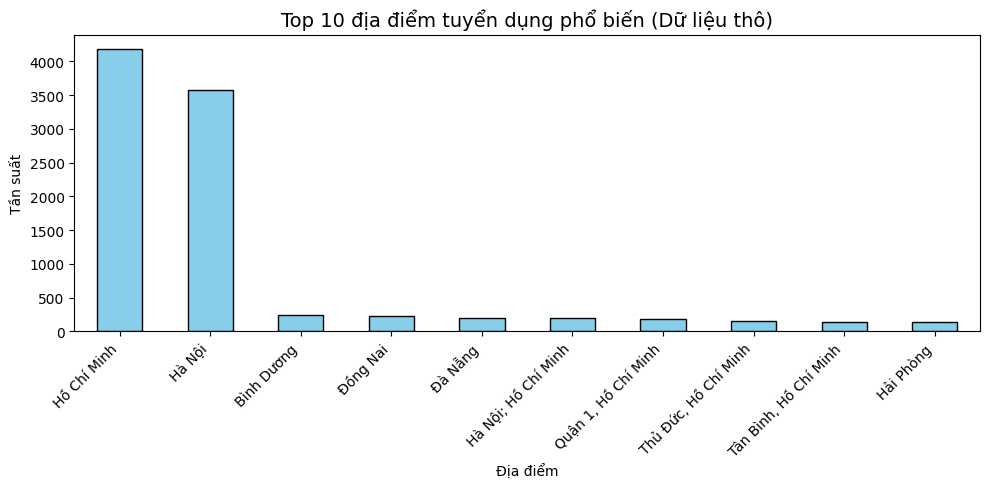

In [102]:
plt.figure(figsize=(10, 5))
raw_train['location'].value_counts().head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 địa điểm tuyển dụng phổ biến (Dữ liệu thô)', fontsize=14)
plt.xlabel('Địa điểm')
plt.ylabel('Tần suất')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

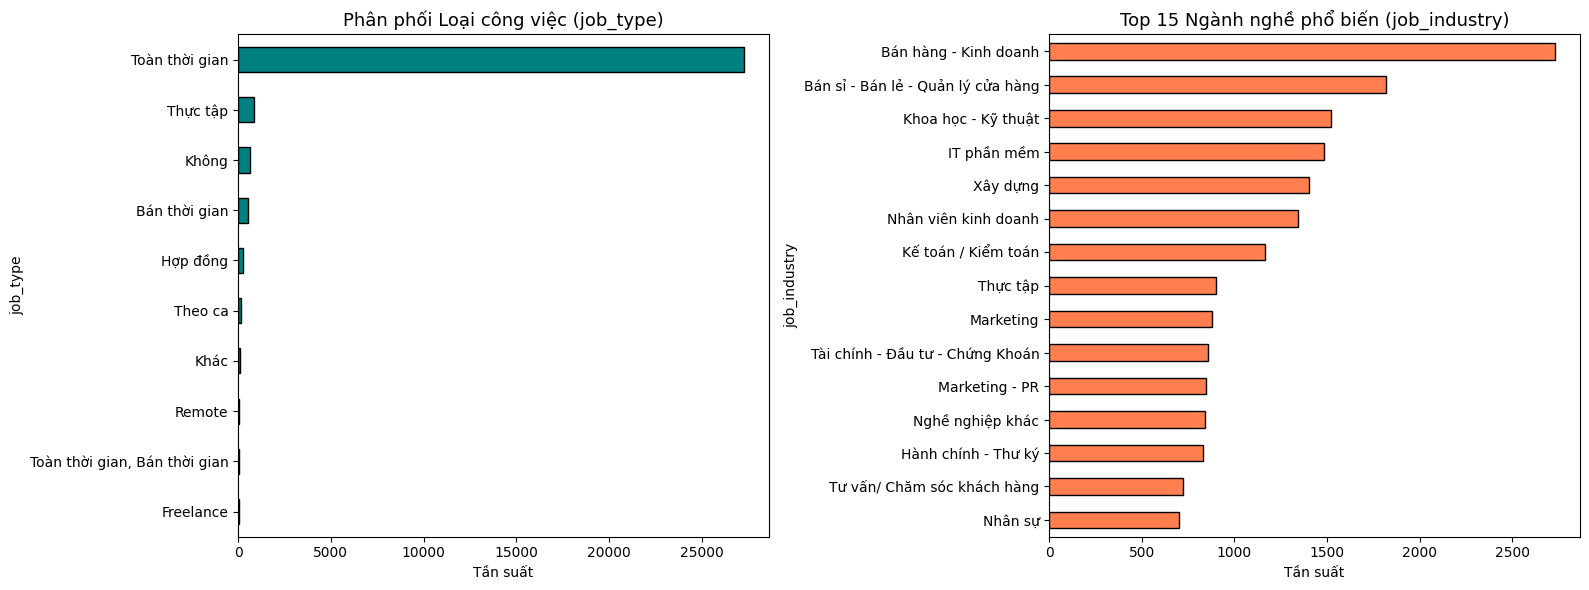

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

raw_train['job_type'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Phân phối Loại công việc (job_type)', fontsize=13)
axes[0].set_xlabel('Tần suất')
axes[0].invert_yaxis()

raw_train['job_industry'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 15 Ngành nghề phổ biến (job_industry)', fontsize=13)
axes[1].set_xlabel('Tần suất')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

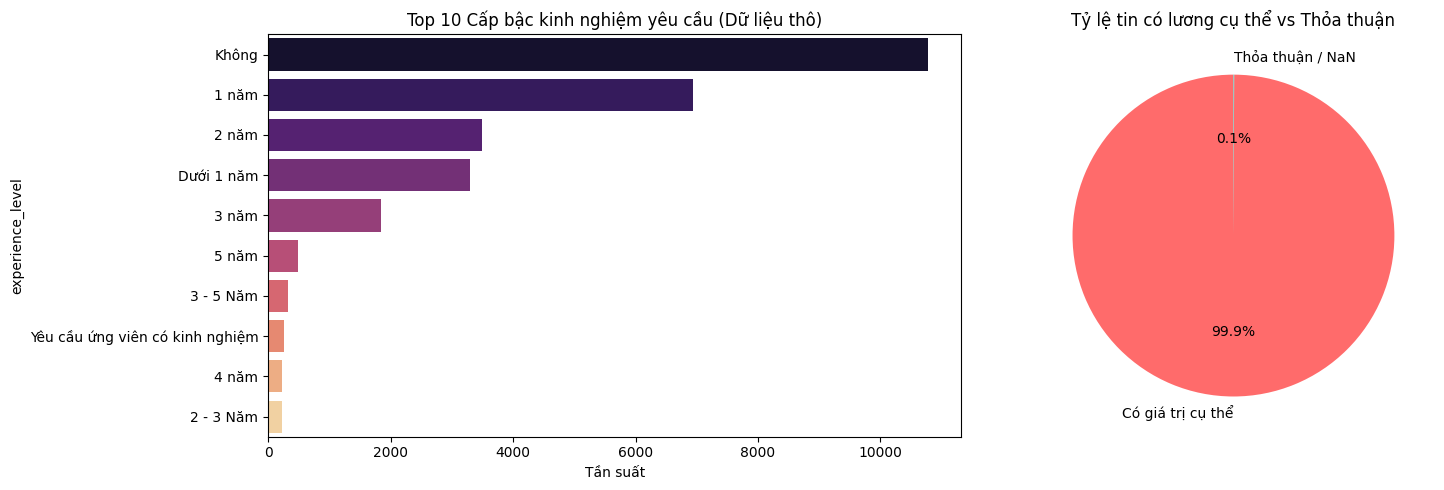

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Phân phối kinh nghiệm thô
exp_counts = raw_train['experience_level'].value_counts().head(10)
sns.barplot(x=exp_counts.values, y=exp_counts.index, ax=axes[0], palette='magma')
axes[0].set_title('Top 10 Cấp bậc kinh nghiệm yêu cầu (Dữ liệu thô)')
axes[0].set_xlabel('Tần suất')

# Tỷ lệ lương 'thỏa thuận' vs có giá trị cụ thể
salary_type = raw_train['salary'].apply(
    lambda x: 'Thỏa thuận / NaN' if pd.isna(x) or
    any(kw in str(x).lower() for kw in ['thỏa thuận','thoả thuận','negotiable'])
    else 'Có giá trị cụ thể'
).value_counts()
axes[1].pie(salary_type, labels=salary_type.index, autopct='%1.1f%%',
            colors=['#FF6B6B','#4ECDC4'], startangle=90)
axes[1].set_title('Tỷ lệ tin có lương cụ thể vs Thỏa thuận')

plt.tight_layout()
plt.show()

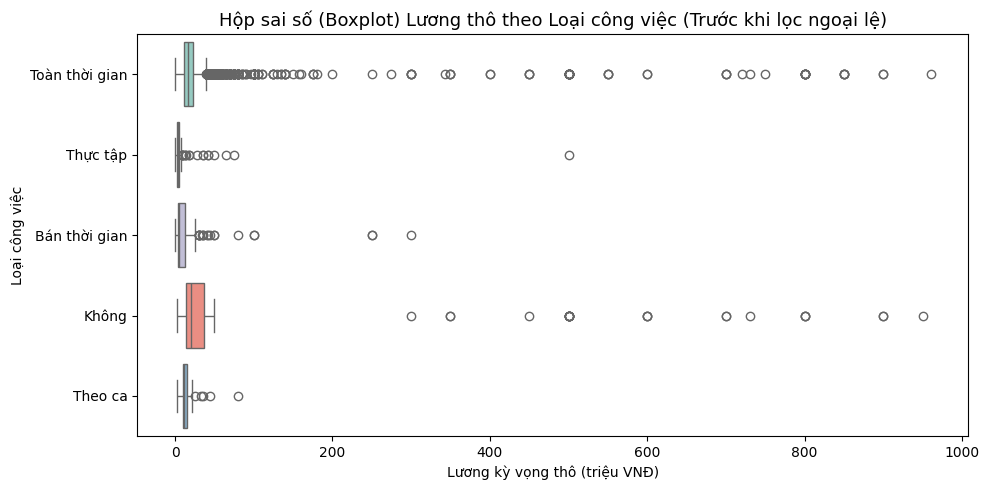

In [105]:
# Hộp sai số (Boxplot) Lương thô theo Loại công việc (Trước khi lọc ngoại lệ)
plt.figure(figsize=(10, 5))
raw_train_with_sal = raw_train.copy()
temp_sal = raw_train_with_sal['salary'].apply(extract_salary_features)
raw_train_with_sal['_Expected_Salary_Raw'] = temp_sal.apply(lambda x: x[2])
raw_train_with_sal = raw_train_with_sal.dropna(subset=['_Expected_Salary_Raw'])

# Lấy 5 loại công việc phổ biến nhất để vẽ boxplot
top_job_types = raw_train_with_sal['job_type'].value_counts().head(5).index
df_boxplot = raw_train_with_sal[raw_train_with_sal['job_type'].isin(top_job_types)]

sns.boxplot(x='_Expected_Salary_Raw', y='job_type', data=df_boxplot, palette='Set3')
plt.title('Hộp sai số (Boxplot) Lương thô theo Loại công việc (Trước khi lọc ngoại lệ)', fontsize=13)
plt.xlabel('Lương kỳ vọng thô (triệu VNĐ)')
plt.ylabel('Loại công việc')
plt.tight_layout()
plt.show()

## 2.4. Phân tích Phân phối Lương, Tính lệch (Skewness) & Ma trận Tương quan

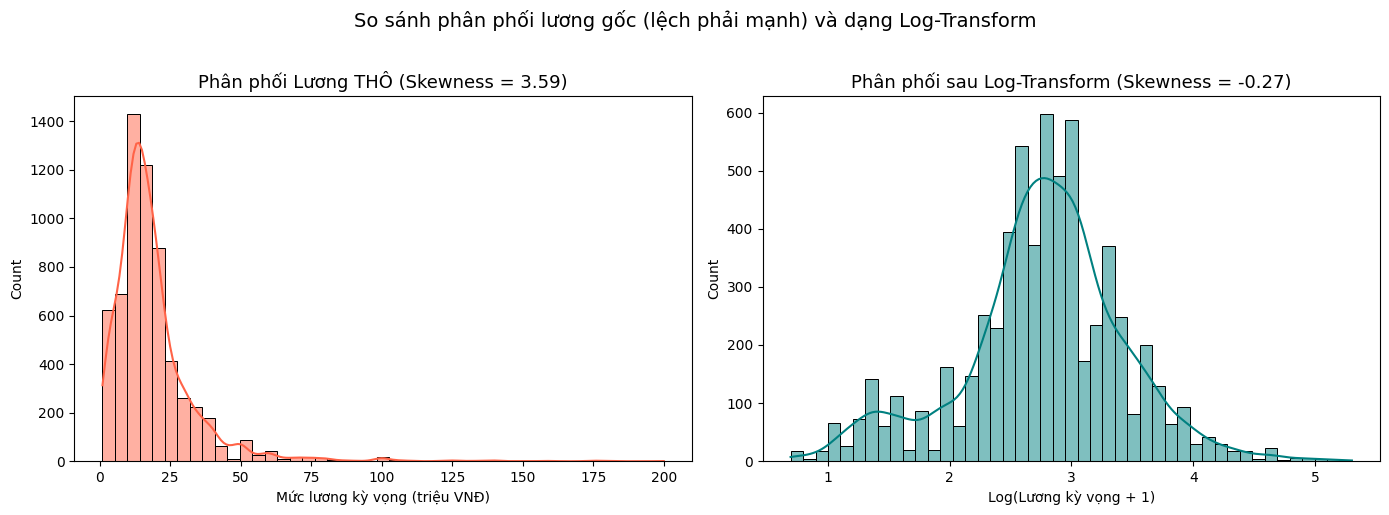

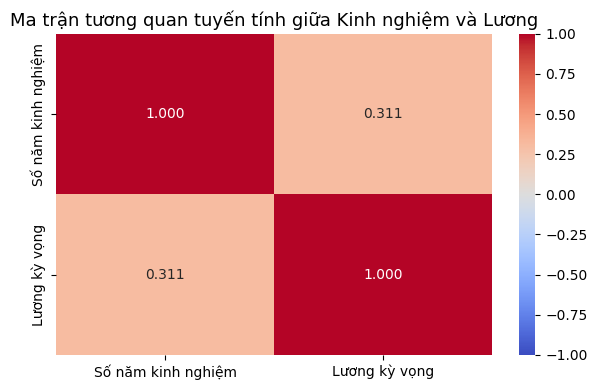

In [106]:
# Khai báo các hàm trích xuất tạm thời phục vụ EDA
def extract_experience_years(exp_str):
    if pd.isna(exp_str):
        return 0.0
    s = str(exp_str).lower()
    if 'dưới 1' in s or 'chưa' in s or 'không' in s:
        return 0.5
    nums = re.findall(r'\d+', s)
    if nums:
        return float(nums[0])
    return 0.0

def extract_salary_features(salary_str):
    if pd.isna(salary_str):
        return np.nan, np.nan, np.nan
    s = str(salary_str).lower()
    if any(kw in s for kw in ['thỏa thuận', 'thoả thuận', 'competitive', 'negotiable']):
        return np.nan, np.nan, np.nan
    numbers = [float(n) for n in re.findall(r'\d+\.?\d*', s)]
    numbers = [n for n in numbers if n < 1000]
    if not numbers:
        return np.nan, np.nan, np.nan
    if len(numbers) >= 2:
        return numbers[0], numbers[1], float(np.mean(numbers[:2]))
    else:
        return numbers[0], numbers[0], numbers[0]

# Trích xuất tạm thời
salary_raw = raw_train['salary'].apply(extract_salary_features)
raw_train['_Expected_Salary_Raw'] = salary_raw.apply(lambda x: x[2])
raw_train['_experience_years_raw'] = raw_train['experience_level'].apply(extract_experience_years)

eda_temp = raw_train.dropna(subset=['_Expected_Salary_Raw']).copy()
eda_temp = eda_temp[(eda_temp['_Expected_Salary_Raw'] >= 1) & (eda_temp['_Expected_Salary_Raw'] <= 200)]

# 1. Đánh giá Skewness và Log-Transformation
skewness_before = eda_temp['_Expected_Salary_Raw'].skew()
skewness_after = np.log1p(eda_temp['_Expected_Salary_Raw']).skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(eda_temp['_Expected_Salary_Raw'], bins=45, kde=True, ax=axes[0], color='tomato')
axes[0].set_title(f'Phân phối Lương THÔ (Skewness = {skewness_before:.2f})', fontsize=13)
axes[0].set_xlabel('Mức lương kỳ vọng (triệu VNĐ)')

sns.histplot(np.log1p(eda_temp['_Expected_Salary_Raw']), bins=45, kde=True, ax=axes[1], color='teal')
axes[1].set_title(f'Phân phối sau Log-Transform (Skewness = {skewness_after:.2f})', fontsize=13)
axes[1].set_xlabel('Log(Lương kỳ vọng + 1)')

plt.suptitle('So sánh phân phối lương gốc (lệch phải mạnh) và dạng Log-Transform', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 2. Ma trận tương quan giữa số năm kinh nghiệm và lương kỳ vọng thô
corr_matrix = eda_temp[['_experience_years_raw', '_Expected_Salary_Raw']].rename(
    columns={'_experience_years_raw': 'Số năm kinh nghiệm', '_Expected_Salary_Raw': 'Lương kỳ vọng'}
).corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title('Ma trận tương quan tuyến tính giữa Kinh nghiệm và Lương', fontsize=13)
plt.tight_layout()
plt.show()

# Dọn dẹp
raw_train.drop(columns=['_Expected_Salary_Raw', '_experience_years_raw'], inplace=True)

## 2.5. Phân tích Lệch phân phối (Distribution Shift) giữa tập Train và Test
Để đảm bảo mô hình huấn luyện trên tập Train có thể tổng quát hóa tốt trên tập Test, chúng ta cần so sánh phân phối của biến mục tiêu (Lương kỳ vọng) và các biến phân loại quan trọng giữa hai tập dữ liệu này. Nếu có sự lệch phân phối lớn, mô hình sẽ gặp khó khăn khi dự báo trên dữ liệu thực tế.


--- PHÂN BỐ ĐỊA ĐIỂM THÔ (TRAIN VS TEST) ---
                                                    Train thô (%)  \
location                                                            
24th floor, Discovery Complex Office Tower, No....           0.00   
442 Nguyễn Thị Minh Khai, Ho Chi Minh                        0.00   
4th and 9th Floor, Block B, Viettel Building, 2...           0.00   
An Dương, Cát Hải, Hải Phòng                                 0.00   
An Dương, Hải Phòng                                          0.01   
An Giang                                                     0.06   
An Giang 03 Đường 3/2, Phường 11, Quận 10, Thàn...           0.00   
An Giang 130 quốc lộ 1A, Phường Ba Láng, Quận C...           0.00   
An Giang 139 Pasteur, Phường Võ Thị Sáu, Quận 3...           0.00   
An Giang 15 Trường Chinh, P. Phù Đổng, Tp. Plei...            NaN   

                                                    Test thô (%)  
location                                                   

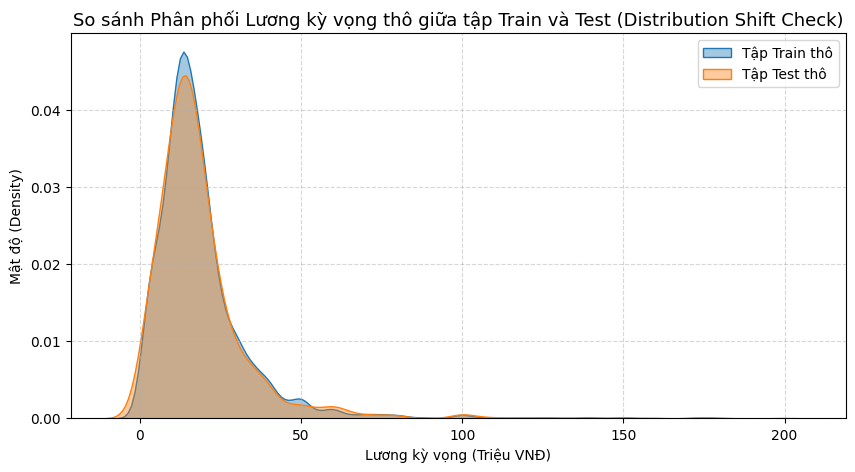

In [107]:
# 1. So sánh tỷ lệ phân phối địa điểm làm việc thô giữa Train và Test
train_loc = raw_train['location'].value_counts(normalize=True) * 100
test_loc = raw_test['location'].value_counts(normalize=True) * 100
loc_compare = pd.DataFrame({'Train thô (%)': train_loc, 'Test thô (%)': test_loc})
print("--- PHÂN BỐ ĐỊA ĐIỂM THÔ (TRAIN VS TEST) ---")
print(loc_compare.head(10).round(2))
print("\n")

# 2. So sánh tỷ lệ phân phối cấp bậc/kinh nghiệm yêu cầu thô giữa Train và Test
train_exp = raw_train['experience_level'].value_counts(normalize=True) * 100
test_exp = raw_test['experience_level'].value_counts(normalize=True) * 100
exp_compare = pd.DataFrame({'Train thô (%)': train_exp, 'Test thô (%)': test_exp})
print("--- PHÂN BỐ CẤP BẬC YÊU CẦU THÔ (TRAIN VS TEST) ---")
print(exp_compare.head(10).round(2))

# 3. Vẽ biểu đồ KDE so sánh phân phối Lương kỳ vọng thô
temp_salary_train = raw_train['salary'].apply(extract_salary_features).apply(lambda x: x[2])
temp_salary_test = raw_test['salary'].apply(extract_salary_features).apply(lambda x: x[2])

# Lọc tạm thời khoảng lương [1.0, 200.0] để đồ thị KDE không bị nhiễu bởi các outlier cực đoan
temp_salary_train = temp_salary_train[(temp_salary_train >= 1) & (temp_salary_train <= 200)]
temp_salary_test = temp_salary_test[(temp_salary_test >= 1) & (temp_salary_test <= 200)]

plt.figure(figsize=(10, 5))
sns.kdeplot(temp_salary_train, label='Tập Train thô', fill=True, alpha=0.4, color='#1f77b4')
sns.kdeplot(temp_salary_test, label='Tập Test thô', fill=True, alpha=0.4, color='#ff7f0e')
plt.title('So sánh Phân phối Lương kỳ vọng thô giữa tập Train và Test (Distribution Shift Check)', fontsize=13)
plt.xlabel('Lương kỳ vọng (Triệu VNĐ)')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# CHƯƠNG 3: LỰA CHỌN ĐẶC TRƯNG, LÀM SẠCH & TIỀN XỬ LÝ DỮ LIỆU

Mục này tập trung trích xuất target, làm sạch văn bản, chuẩn hóa địa chỉ, trích xuất đặc trưng số của kinh nghiệm, thiết lập bộ chống rò rỉ dữ liệu (Anti-Data Leakage), và áp dụng các giải pháp lựa chọn đặc trưng & giảm chiều dữ liệu.


# CHƯƠNG 3: QUY TRÌNH TIỀN XỬ LÝ & LÀM SẠCH DỮ LIỆU

Mục này tập trung trích xuất target, làm sạch văn bản, chuẩn hóa địa chỉ, trích xuất đặc trưng số của kinh nghiệm và thiết lập bộ chống rò rỉ dữ liệu (Anti-Data Leakage).

## 3.1. Trích xuất lương & Lọc ngoại lệ

In [108]:
print('Đang trích xuất cột lương...')
salary_features = raw_train['salary'].apply(extract_salary_features)
raw_train['Salary_Min'] = salary_features.apply(lambda x: x[0])
raw_train['Salary_Max'] = salary_features.apply(lambda x: x[1])
raw_train['Expected_Salary'] = salary_features.apply(lambda x: x[2])

df_before_filter = raw_train.dropna(subset=['Expected_Salary']).copy()
print(f'Dòng có lương xác định: {len(df_before_filter):,}')

clean_train = df_before_filter[
    (df_before_filter['Expected_Salary'] >= 1) &
    (df_before_filter['Expected_Salary'] <= 200)
].copy()
print(f'Dòng sau khi lọc ngoại lệ [1, 200]: {len(clean_train):,}')
print(f'Số dòng bị loại: {len(df_before_filter) - len(clean_train):,}')

Đang trích xuất cột lương...
Dòng có lương xác định: 6,382
Dòng sau khi lọc ngoại lệ [1, 200]: 6,253
Số dòng bị loại: 129


## 3.2. Biện minh ngưỡng lọc bằng phân tích IQR

In [109]:
# Phân tích IQR
Q1 = clean_train['Expected_Salary'].quantile(0.25)
Q3 = clean_train['Expected_Salary'].quantile(0.75)
IQR = Q3 - Q1
iqr_lower = Q1 - 1.5 * IQR
iqr_upper = Q3 + 1.5 * IQR

print(f'Q1 = {Q1:.1f} triệu | Q3 = {Q3:.1f} triệu | IQR = {IQR:.1f} triệu')
print(f'Ngưỡng IQR lý thuyết để phát hiện outlier: [{iqr_lower:.1f}, {iqr_upper:.1f}] triệu')
print(f'Ngưỡng thực tế nhóm giữ lại: [1.0, 200.0] triệu VNĐ')
print('\n=> Biện giải học thuật:')
print('   Phân tích IQR lý thuyết đề xuất loại bỏ toàn bộ lương trên 35 triệu VNĐ.')
print('   Tuy nhiên, tại Việt Nam, các vị trí IT/AI, Senior Manager hoặc Tech Lead')
print('   hoàn toàn đạt mức thu nhập thực tế 40-150 triệu VNĐ.')
print('   Do đó, việc duy trì ngưỡng rộng [1, 200] triệu VNĐ giúp bảo toàn các dữ liệu')
print('   đại diện cho phân khúc lương cao có ý nghĩa thực tiễn, tránh làm nghèo nàn thông tin tuyển dụng.')

Q1 = 10.5 triệu | Q3 = 22.5 triệu | IQR = 12.0 triệu
Ngưỡng IQR lý thuyết để phát hiện outlier: [-7.5, 40.5] triệu
Ngưỡng thực tế nhóm giữ lại: [1.0, 200.0] triệu VNĐ

=> Biện giải học thuật:
   Phân tích IQR lý thuyết đề xuất loại bỏ toàn bộ lương trên 35 triệu VNĐ.
   Tuy nhiên, tại Việt Nam, các vị trí IT/AI, Senior Manager hoặc Tech Lead
   hoàn toàn đạt mức thu nhập thực tế 40-150 triệu VNĐ.
   Do đó, việc duy trì ngưỡng rộng [1, 200] triệu VNĐ giúp bảo toàn các dữ liệu
   đại diện cho phân khúc lương cao có ý nghĩa thực tiễn, tránh làm nghèo nàn thông tin tuyển dụng.


## 3.3. So sánh Phân phối Trước – Sau khi lọc ngoại lệ

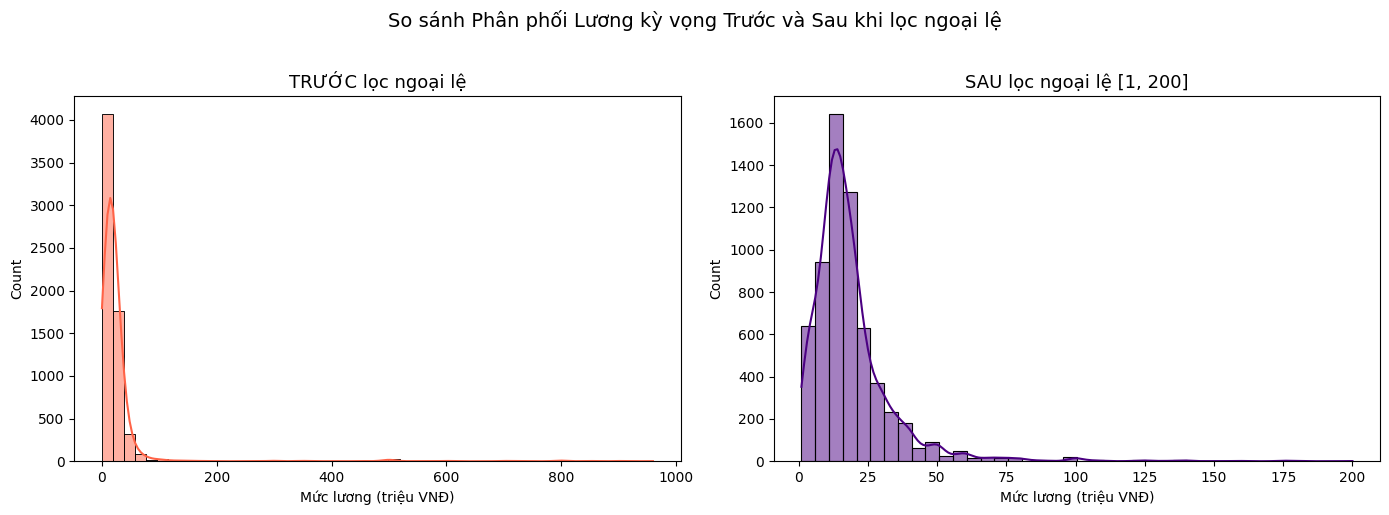

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_before_filter['Expected_Salary'], bins=50, kde=True, ax=axes[0], color='tomato')
axes[0].set_title('TRƯỚC lọc ngoại lệ', fontsize=13)
axes[0].set_xlabel('Mức lương (triệu VNĐ)')

sns.histplot(clean_train['Expected_Salary'], bins=40, kde=True, ax=axes[1], color='indigo')
axes[1].set_title('SAU lọc ngoại lệ [1, 200]', fontsize=13)
axes[1].set_xlabel('Mức lương (triệu VNĐ)')

plt.suptitle('So sánh Phân phối Lương kỳ vọng Trước và Sau khi lọc ngoại lệ', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

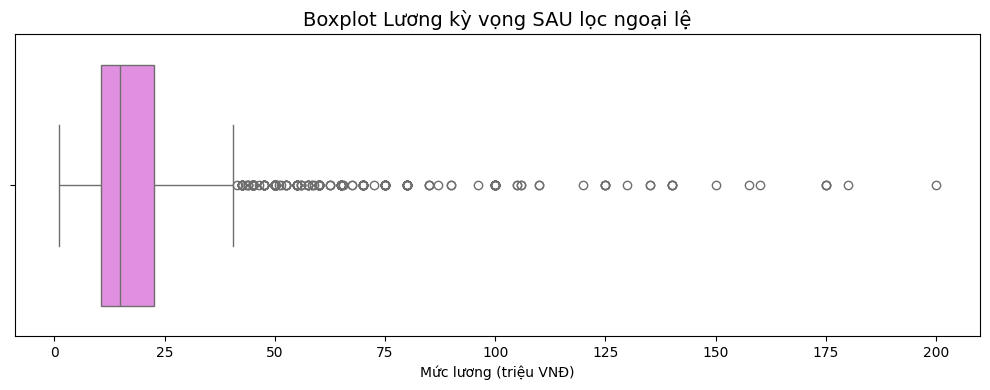

In [111]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=clean_train['Expected_Salary'], color='violet')
plt.title('Boxplot Lương kỳ vọng SAU lọc ngoại lệ', fontsize=14)
plt.xlabel('Mức lương (triệu VNĐ)')
plt.tight_layout()
plt.show()

## 3.4. Chuẩn hóa Địa điểm & Phân phối Lương

In [112]:
def normalize_location(loc_str):
    if pd.isna(loc_str):
        return 'Khác'
    s = str(loc_str).lower()
    mapping = {
        'ho chi minh': 'Hồ Chí Minh', 'hồ chí minh': 'Hồ Chí Minh', 'hcm': 'Hồ Chí Minh', 'tp.hcm': 'Hồ Chí Minh',
        'ha noi': 'Hà Nội', 'hà nội': 'Hà Nội', 'hanoi': 'Hà Nội',
        'da nang': 'Đà Nẵng', 'đà nẵng': 'Đà Nẵng',
        'binh duong': 'Bình Dương', 'bình dương': 'Bình Dương',
        'dong nai': 'Đồng Nai', 'đồng nai': 'Đồng Nai',
        'hai phong': 'Hải Phòng', 'hải phòng': 'Hải Phòng',
        'can tho': 'Cần Thơ', 'cần thơ': 'Cần Thơ',
        'bac ninh': 'Bắc Ninh', 'bắc ninh': 'Bắc Ninh',
        'long an': 'Long An',
    }
    for key, val in mapping.items():
        if key in s:
            return val
    return 'Khác'

clean_train['location'] = clean_train['location'].apply(normalize_location)
loc_counts = clean_train['location'].value_counts()
print('Phân phối địa điểm SAU chuẩn hóa:')
print(loc_counts)
print(f'\nTỷ lệ nhóm "Khác": {loc_counts.get("Khác", 0) / len(clean_train) * 100:.2f}%')

Phân phối địa điểm SAU chuẩn hóa:
location
Hồ Chí Minh    2617
Hà Nội         2495
Khác            573
Đà Nẵng         112
Đồng Nai         96
Bình Dương       91
Hải Phòng        90
Cần Thơ          80
Bắc Ninh         69
Long An          30
Name: count, dtype: int64

Tỷ lệ nhóm "Khác": 9.16%


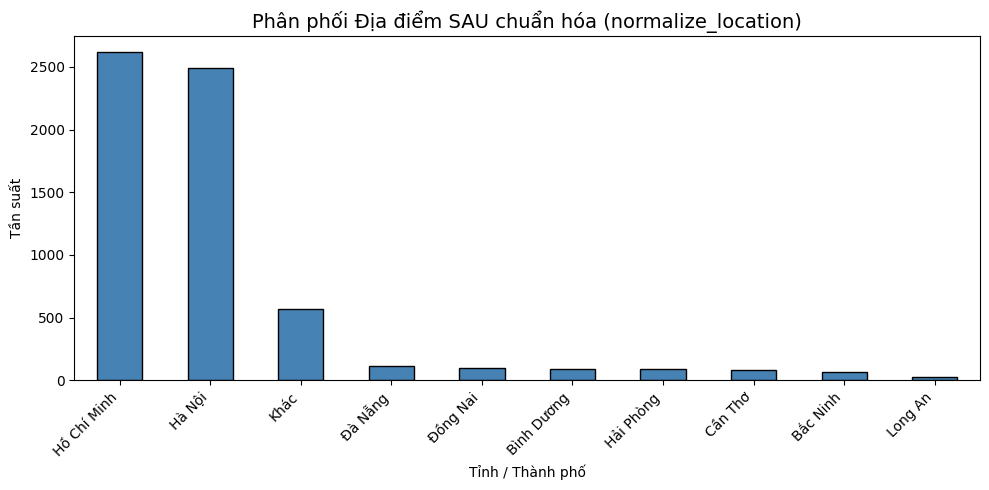

In [113]:
plt.figure(figsize=(10, 5))
clean_train['location'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Phân phối Địa điểm SAU chuẩn hóa (normalize_location)', fontsize=14)
plt.xlabel('Tỉnh / Thành phố')
plt.ylabel('Tần suất')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3.5. Trích xuất Kinh nghiệm & Phân tích tương quan

In [114]:
clean_train['experience_years'] = clean_train['experience_level'].apply(extract_experience_years)

# Điền giá trị khuyết của experience_years bằng trung vị (median) của tập train để tránh lỗi NaN ở Ridge
exp_median = clean_train['experience_years'].median()
clean_train['experience_years'] = clean_train['experience_years'].fillna(exp_median)

print(f'Trung vị số năm kinh nghiệm: {exp_median} năm')
print('Phân phối số năm kinh nghiệm (sau khi điền khuyết):')
print(clean_train['experience_years'].value_counts().sort_index())


Trung vị số năm kinh nghiệm: 0.5 năm
Phân phối số năm kinh nghiệm (sau khi điền khuyết):
experience_years
0.0      145
0.5     2990
1.0     1258
2.0      912
3.0      621
4.0       99
5.0      166
6.0       38
7.0       11
8.0        6
10.0       7
Name: count, dtype: int64


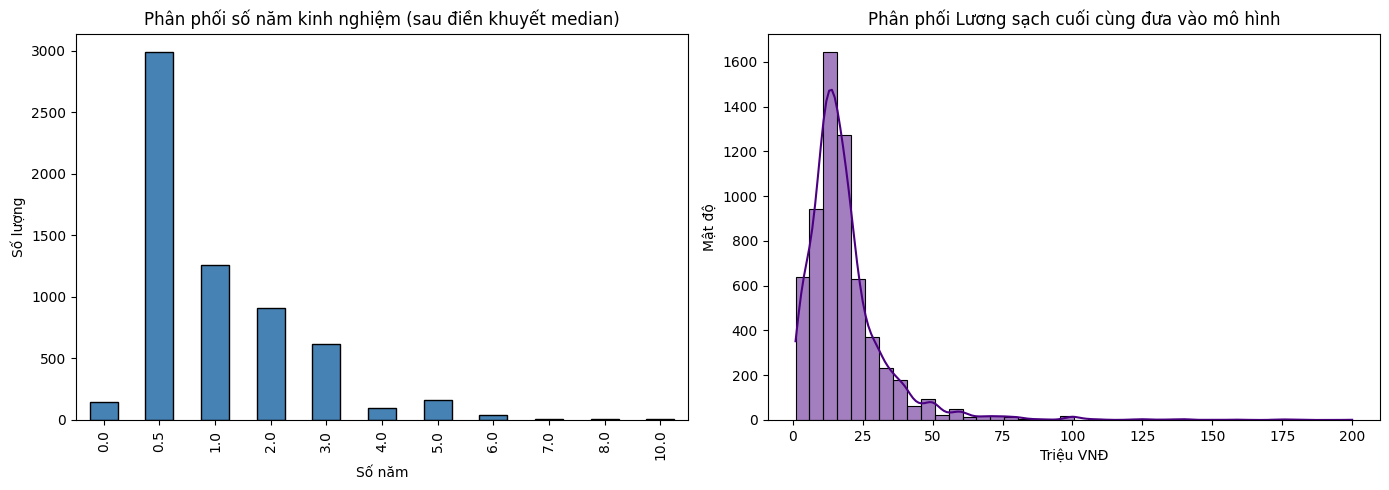

In [115]:
# Biểu đồ phân phối số năm kinh nghiệm và Expected_Salary sau làm sạch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clean_train['experience_years'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Phân phối số năm kinh nghiệm (sau điền khuyết median)')
axes[0].set_xlabel('Số năm')
axes[0].set_ylabel('Số lượng')

sns.histplot(clean_train['Expected_Salary'], bins=40, kde=True, ax=axes[1], color='indigo')
axes[1].set_title('Phân phối Lương sạch cuối cùng đưa vào mô hình')
axes[1].set_xlabel('Triệu VNĐ')
axes[1].set_ylabel('Mật độ')

plt.tight_layout()
plt.show()


## 3.6. Phân tích Lương theo Địa điểm và Ngành nghề (Hậu Tiền xử lý)

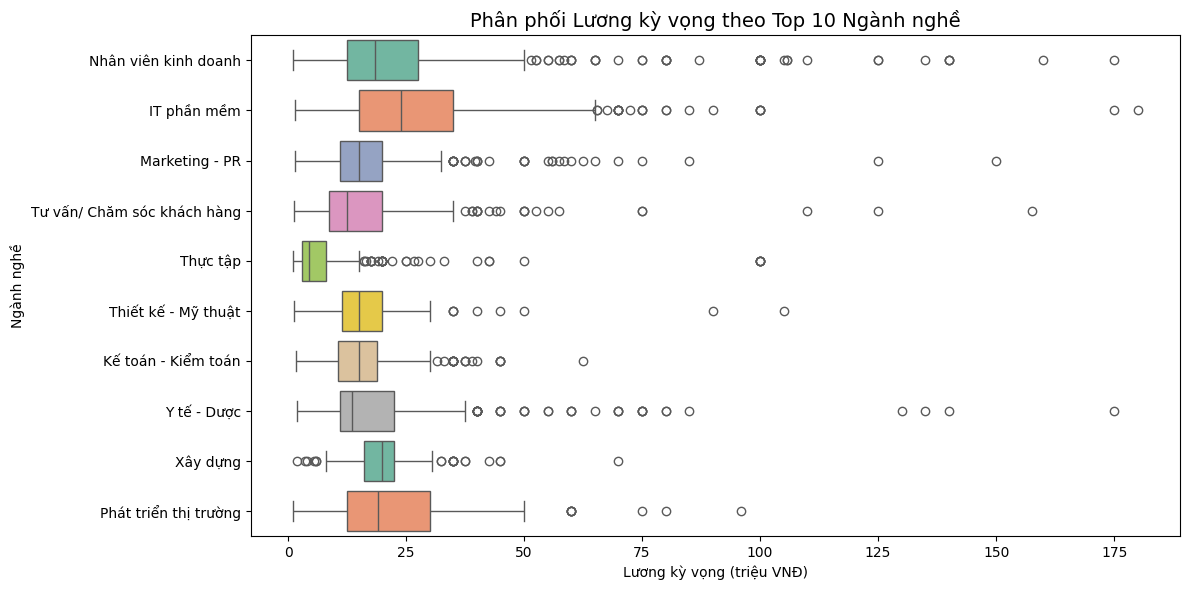

In [116]:
# Boxplot lương theo 10 ngành hàng đầu
clean_train['job_industry'] = clean_train['job_industry'].fillna('Unknown')
top_industries = clean_train['job_industry'].value_counts().head(10).index
df_top_ind = clean_train[clean_train['job_industry'].isin(top_industries)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Expected_Salary', y='job_industry', data=df_top_ind,
            order=top_industries, palette='Set2')
plt.title('Phân phối Lương kỳ vọng theo Top 10 Ngành nghề', fontsize=14)
plt.xlabel('Lương kỳ vọng (triệu VNĐ)')
plt.ylabel('Ngành nghề')
plt.tight_layout()
plt.show()

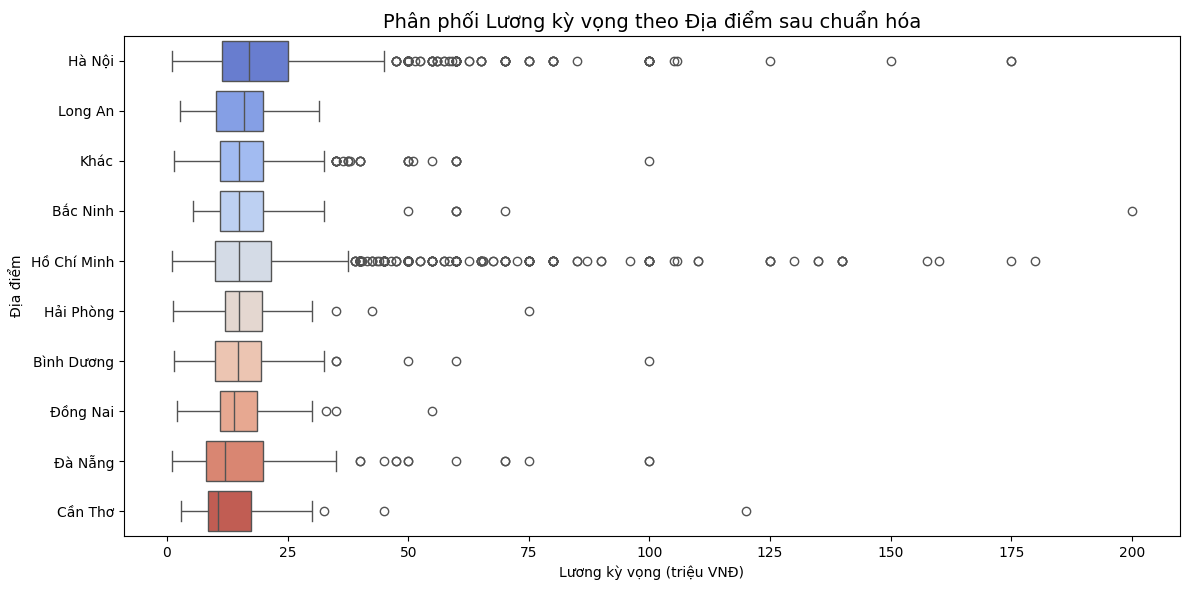

In [117]:
# Boxplot lương theo Địa điểm sau chuẩn hóa
loc_order = clean_train.groupby('location')['Expected_Salary'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(x='Expected_Salary', y='location', data=clean_train,
            order=loc_order, palette='coolwarm')
plt.title('Phân phối Lương kỳ vọng theo Địa điểm sau chuẩn hóa', fontsize=14)
plt.xlabel('Lương kỳ vọng (triệu VNĐ)')
plt.ylabel('Địa điểm')
plt.tight_layout()
plt.show()

## 3.7. Chống rò rỉ dữ liệu (Anti-Leakage), Làm sạch Văn bản & Loại bỏ Stopwords

In [118]:
# Danh sách stopword tiếng Việt cơ bản xuất hiện nhiều trong JD
VIETNAMESE_STOPWORDS = {
    'và', 'của', 'được', 'các', 'cho', 'trong', 'có', 'là', 'để', 'với', 'tại', 
    'những', 'một', 'này', 'như', 'đã', 'sự', 'về', 'nhưng', 'khi', 'ra', 'vào',
    'lại', 'thế', 'nào', 'nơi', 'nếu', 'như_vậy', 'vì_thế', 'tuy_nhiên', 'cũng'
}

def strip_salary_leakage(text):
    """
    Loại bỏ các thông tin mức lương đề cập trực tiếp trong JD để tránh mô hình học thuộc lòng.
    Ví dụ: 'lương up to 15m', 'lương 20 triệu', 'thu nhập 1500 usd'
    """
    if not isinstance(text, str):
        return ''
    s = text.lower()
    # Xóa các cụm số liên quan đến đơn vị lương: triệu, tr, m, k, usd, vnd, vnđ
    s = re.sub(r'\b\d+\s*(triệu|tỷ|tr|m|k|usd|vnd|vnđ|ttr|vnd/tháng|usd/month)\b', ' ', s)
    s = re.sub(r'\b\d+\.\d+\s*(triệu|tỷ|tr|m|k|usd|vnd|vnđ|ttr)\b', ' ', s)
    s = re.sub(r'\b\d+k\b|\b\d+m\b', ' ', s)
    # Xóa các từ chỉ mức lương thông thường
    s = re.sub(r'\blương\b|\bsalary\b|\bthu nhập\b|\bnegotiable\b|\bthỏa thuận\b|\bthoả thuận\b|\bcompetitive\b', ' ', s)
    return s

def clean_text(text):
    if pd.isna(text):
        return ''
    
    # 1. Chống rò rỉ dữ liệu
    text = strip_salary_leakage(text)
    
    # Tách từ ghép tiếng Việt chuyên sâu bằng pyvi
    text = ViTokenizer.tokenize(text)
    
    # 2. Xóa ký tự đặc biệt, chuẩn hóa chữ thường
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 3. Loại stopword tiếng Việt và từ quá ngắn
    words = text.split()
    words = [w for w in words if w not in VIETNAMESE_STOPWORDS and len(w) > 1]
    
    return ' '.join(words)

clean_train['job_description'] = clean_train['job_description'].apply(clean_text)
clean_train['requirements'] = clean_train['requirements'].apply(clean_text)
clean_train['combined_text'] = clean_train['job_description'] + ' ' + clean_train['requirements']

categorical_cols = ['location', 'job_type', 'experience_level', 'job_industry']
for col in categorical_cols:
    clean_train[col] = clean_train[col].fillna('Unknown')

clean_train.to_csv('clean_data_train.csv', index=False)
print(f'Đã lưu clean_data_train.csv ({len(clean_train):,} dòng)')


Đã lưu clean_data_train.csv (6,253 dòng)


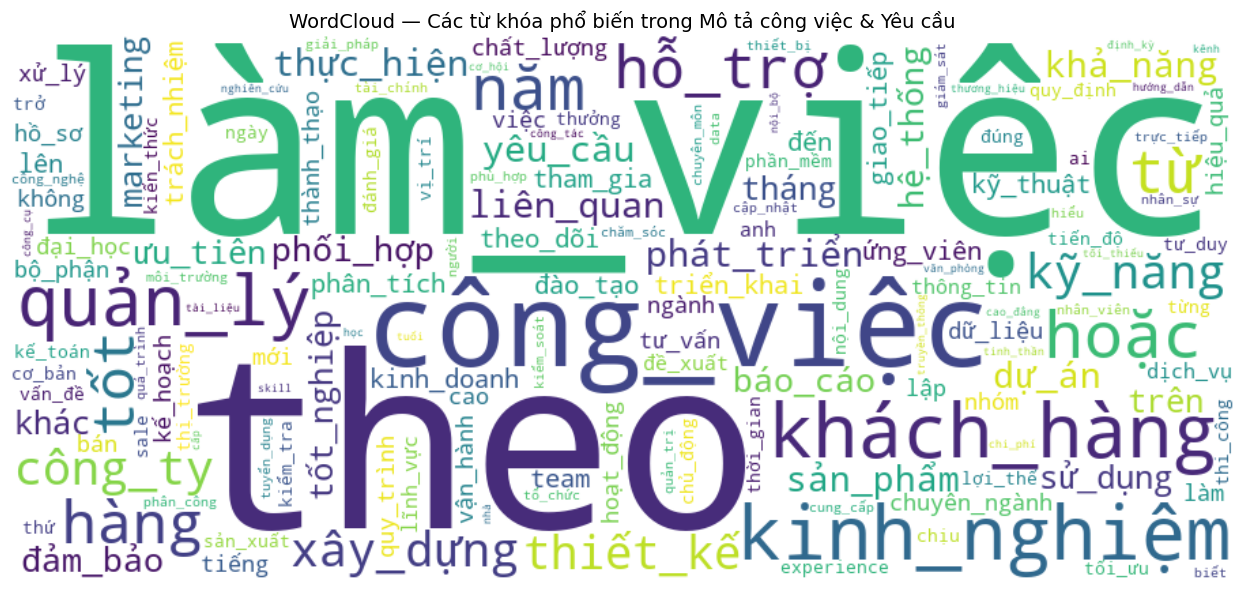

In [119]:
all_text = ' '.join(clean_train['combined_text'].head(5000).tolist())
wc = WordCloud(width=900, height=400, background_color='white', max_words=150,
               colormap='viridis', collocations=False).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Các từ khóa phổ biến trong Mô tả công việc & Yêu cầu', fontsize=14)
plt.tight_layout()
plt.show()

## 3.8. Tổng kết Lựa chọn Đặc trưng & Giảm chiều dữ liệu

### 3.8.1. Lựa chọn Đặc trưng (Feature Selection)
Để tối ưu hiệu năng dự báo và giảm nhiễu thông tin, nhóm tiến hành lựa chọn các đặc trưng đầu vào dựa trên nghiệp vụ tuyển dụng và độ tương quan dữ liệu:
* **Đặc trưng giữ lại**:
  * `combined_text`: Bản mô tả công việc (JD) đã gộp từ `job_title`, `job_description`, `requirements` và `benefits`. Đây là nguồn thông tin cốt lõi chứa các từ khóa kỹ năng, trách nhiệm phục vụ định giá lương.
  * `location` (sau chuẩn hóa): Địa điểm làm việc quyết định mức sống và mặt bằng lương khu vực.
  * `job_type`, `job_position`, `job_industry`: Các yếu tố định danh hình thức, chức danh và lĩnh vực công việc.
  * `experience_years`: Số năm kinh nghiệm (biến số liên tục có tương quan tuyến tính mạnh nhất với mức lương thực tế).
* **Đặc trưng loại bỏ**:
  * `id`: Định danh tin tuyển dụng không có giá trị học máy.
  * `year`: Toàn bộ dữ liệu thu thập trong cùng một năm, không có ý nghĩa biến thiên thời gian.
  * `salary` gốc: Bị loại bỏ sau khi đã trích xuất ra biến mục tiêu `Expected_Salary` để tránh rò rỉ thông tin trực tiếp cho mô hình (Target Leakage).

### 3.8.2. Giảm chiều dữ liệu (Dimensionality Reduction)
Nhóm áp dụng 2 phương pháp giảm chiều dữ liệu chính để giải quyết bài toán đặc trưng thưa lớn (high-dimensional sparse feature space), kiểm soát rủi ro "lời nguyền đa chiều" (curse of dimensionality):
1. **Gom cụm tần suất thấp (Categorical Cardinality Reduction)**:
   * *Cách làm*: Các tỉnh thành hoặc ngành nghề xuất hiện với tỷ lệ cực ít ($< 1\%$) được gom chung vào một nhóm mang tên `'Khác'` (ví dụ chuẩn hóa từ hàng trăm tỉnh thành/địa chỉ viết tay về chỉ còn 10 nhóm địa điểm chính).
   * *Tác dụng*: Giảm số lượng cột được tạo ra sau khi mã hóa One-Hot Encoder, hạn chế sự thưa thớt của ma trận dữ liệu phân loại.
2. **Giới hạn số lượng đặc trưng văn bản (Textual Dimension Constraint)**:
   * *Cách làm*: Trong quy trình TF-IDF Vectorizer cho cột `combined_text`, nhóm giới hạn `max_features = 2500` (lựa chọn này dựa trên thực nghiệm tối ưu hóa RMSE chéo tại Cell 45).
   * *Tác dụng*: Thay vì giữ lại hàng chục ngàn từ đơn/từ ghép tiếng Việt xuất hiện rải rác, mô hình chỉ tập trung vào 2500 từ có trọng số TF-IDF lớn và phổ biến nhất. Điều này giảm đáng kể số chiều đầu vào mô hình, tăng tốc độ hội tụ và ngăn ngừa hiện tượng quá khớp (overfitting) hiệu quả.

### 3.8.3. Trực quan hóa kết quả trước và sau khi xử lý đặc trưng
Hiệu quả và tác động của quy trình tiền xử lý/trích xuất đặc trưng được trực quan hóa rõ ràng qua các biểu đồ:
* **Biểu đồ phân phối lương (Cell 26, 27)**: So sánh trực quan phân phối mức lương lệch phải cực đoan ban đầu và phân phối chuẩn hóa, ổn định sau khi lọc ngoại lệ bằng IQR và biến đổi Target Log-Transform.
* **Biểu đồ phân phối địa điểm (Cell 12 vs Cell 30)**: Minh họa việc thu gọn từ các địa chỉ lộn xộn, tự do ban đầu về biểu đồ cột sạch sẽ với 10 vùng địa điểm chuẩn hóa chính.
* **Biểu đồ tương quan (Cell 17 vs Cell 33)**: Thể hiện mối tương quan rõ ràng hơn giữa số năm kinh nghiệm và mức lương kỳ vọng sau khi được bóc tách số học so với dữ liệu văn bản gốc.

In [120]:
print('Đang tiền xử lý tập Test...')
raw_test = pd.read_csv('raw_data_test.csv')

test_salary = raw_test['salary'].apply(extract_salary_features)
raw_test['Salary_Min'] = test_salary.apply(lambda x: x[0])
raw_test['Salary_Max'] = test_salary.apply(lambda x: x[1])
raw_test['Expected_Salary'] = test_salary.apply(lambda x: x[2])

clean_test = raw_test.dropna(subset=['Expected_Salary']).copy()
clean_test = clean_test[
    (clean_test['Expected_Salary'] >= 1) &
    (clean_test['Expected_Salary'] <= 200)
].copy()

clean_test['location'] = clean_test['location'].apply(normalize_location)
clean_test['experience_years'] = clean_test['experience_level'].apply(extract_experience_years)

# Điền khuyết bằng trung vị (median) của tập train để chống rò rỉ dữ liệu
clean_test['experience_years'] = clean_test['experience_years'].fillna(exp_median)

clean_test['job_description'] = clean_test['job_description'].apply(clean_text)
clean_test['requirements'] = clean_test['requirements'].apply(clean_text)
clean_test['combined_text'] = clean_test['job_description'] + ' ' + clean_test['requirements']

for col in categorical_cols:
    clean_test[col] = clean_test[col].fillna('Unknown')

clean_test.to_csv('clean_data_test.csv', index=False)
print(f'Đã lưu clean_data_test.csv ({len(clean_test):,} dòng)')


Đang tiền xử lý tập Test...
Đã lưu clean_data_test.csv (1,563 dòng)


# CHƯƠNG 4: XÂY DỰNG PIPELINE HUẤN LUYỆN MÔ HÌNH

## 4.1. Chia tập dữ liệu & Phương pháp xác thực chéo (Cross-Validation)

Để xây dựng và đánh giá mô hình học máy một cách khách quan, dữ liệu được phân chia như sau:
* **Tập Huấn luyện (Train Set)**: Gồm **30.000 dòng** (~80% dữ liệu thô), được sử dụng để huấn luyện mô hình và tinh chỉnh các tham số.
* **Tập Kiểm thử (Test Set)**: Gồm **7.500 dòng** (~20% dữ liệu thô), hoàn toàn độc lập với tập huấn luyện, được giữ lại làm tập kiểm thử cuối cùng để đánh giá khả năng tổng quát hóa của mô hình trên dữ liệu mới.
* **Phương pháp Xác thực (Validation Set)**: Nhóm áp dụng kỹ thuật **5-Fold Cross-Validation** trên tập Huấn luyện. Tập huấn luyện được chia ngẫu nhiên thành 5 phần bằng nhau (folds). Trong mỗi lần lặp, mô hình được huấn luyện trên 4 phần và đánh giá (xác thực) trên phần còn lại. Điểm đánh giá trung bình qua 5 lần lặp là thước đo độ ổn định chính xác của mô hình và giúp ngăn chặn hiện tượng quá khớp (overfitting).

### Thiết lập tiền xử lý trong Pipeline:
Chúng ta sử dụng `ColumnTransformer` để đóng gói toàn bộ quy trình tiền xử lý:
1. **Dữ liệu văn bản (`combined_text`)**: Mã hóa bằng `TfidfVectorizer` (dùng tối đa 2500 đặc trưng, mở rộng sang n-gram từ 1 đến 2 từ ghép).
2. **Dữ liệu phân loại (`location`, `experience_level`, `job_type`, `job_position`, `job_industry`)**: Sử dụng mã hóa `OneHotEncoder`.
3. **Dữ liệu số (`experience_years`)**: Truyền thẳng qua (`passthrough`).
4. **Biến mục tiêu (`Expected_Salary`)**: Áp dụng phép biến đổi Log-Transformation ($y_{trans} = \log(y + 1)$) thông qua `TransformedTargetRegressor` để giảm thiểu độ lệch phải (skewness) của dữ liệu lương thô, giúp các mô hình hồi quy tuyến tính và cây quyết định hội tụ tốt hơn.


In [121]:
feature_cols = ['combined_text'] + categorical_cols + ['experience_years']
X_train = clean_train[feature_cols]
y_train = clean_train['Expected_Salary']

X_test = clean_test[feature_cols]
y_test = clean_test['Expected_Salary']

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (6253, 6), X_test: (1563, 6)


In [122]:
# TF-IDF nâng cấp sử dụng Bigrams để bắt được cụm kỹ năng
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, sublinear_tf=True, ngram_range=(1, 2)), 'combined_text'),
        ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
        ('num',  'passthrough', ['experience_years'])
    ])


In [123]:
def calculate_ram(y_pred, y_min, y_max, epsilon=1.0):
    in_range = (y_pred >= y_min - epsilon) & (y_pred <= y_max + epsilon)
    return np.mean(in_range) * 100

=== Thực nghiệm lựa chọn max_features TF-IDF ===
  max_features= 500 → CV RMSE = 12.825
  max_features=1000 → CV RMSE = 12.477
  max_features=1500 → CV RMSE = 12.474
  max_features=2000 → CV RMSE = 12.499
  max_features=2500 → CV RMSE = 12.444
  max_features=3000 → CV RMSE = 12.479


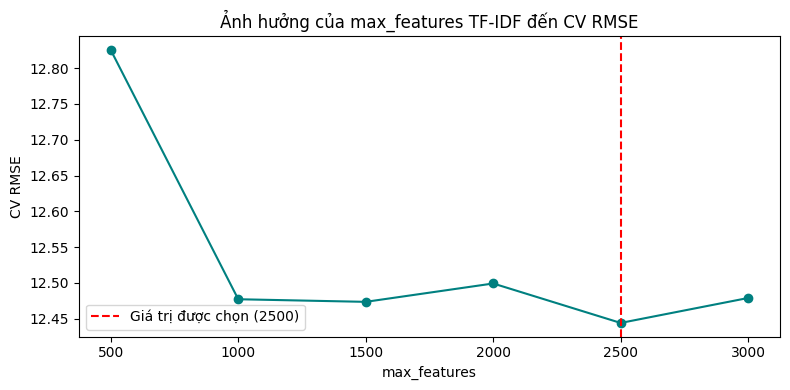

=== KIẾN TRÚC PIPELINE ===
Input features:
  combined_text (6253 dòng) → TF-IDF Bigrams (2500 features)
  categorical   (4 cột) → OneHotEncoder (sparse_output=True)
  experience_years               → passthrough (1 feature)

Target: log1p(Expected_Salary) → TransformedTargetRegressor → expm1(ŷ)
Tổng số đặc trưng đầu vào mô hình sau mã hóa: 2748 (TF-IDF: 2500, One-Hot: 247, Số: 1)


In [124]:
print("=== Thực nghiệm lựa chọn max_features TF-IDF ===")
tfidf_results = []
for n_features in [500, 1000, 1500, 2000, 2500, 3000]:
    probe_pre = ColumnTransformer(transformers=[
        ('text', TfidfVectorizer(max_features=n_features, sublinear_tf=True,
                                 ngram_range=(1,2)), 'combined_text'),
        ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
        ('num',  'passthrough', ['experience_years'])
    ])
    probe_pipe = Pipeline([('pre', probe_pre),
                           ('reg', LGBMRegressor(n_estimators=100,
                                                  random_state=RANDOM_STATE,
                                                  verbose=-1))])
    probe_wrap = TransformedTargetRegressor(
        regressor=probe_pipe, func=np.log1p, inverse_func=np.expm1)
    cv_s = cross_val_score(probe_wrap, X_train, y_train, cv=3,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
    tfidf_results.append({'max_features': n_features, 'CV RMSE': -cv_s.mean()})
    print(f"  max_features={n_features:4d} → CV RMSE = {-cv_s.mean():.3f}")

tfidf_df = pd.DataFrame(tfidf_results)
plt.figure(figsize=(8, 4))
plt.plot(tfidf_df['max_features'], tfidf_df['CV RMSE'], marker='o', color='teal')
plt.axvline(x=2500, color='red', linestyle='--', label='Giá trị được chọn (2500)')
plt.title('Ảnh hưởng của max_features TF-IDF đến CV RMSE')
plt.xlabel('max_features')
plt.ylabel('CV RMSE')
plt.legend()
plt.tight_layout()
plt.show()

print("=== KIẾN TRÚC PIPELINE ===")
print("Input features:")
print(f"  combined_text ({len(X_train)} dòng) → TF-IDF Bigrams (2500 features)")
print(f"  categorical   ({len(categorical_cols)} cột) → OneHotEncoder (sparse_output=True)")
print(f"  experience_years               → passthrough (1 feature)")
print(f"\nTarget: log1p(Expected_Salary) → TransformedTargetRegressor → expm1(ŷ)")

# Tính toán số lượng feature thực tế
text_features = 2500
cat_features = sum(clean_train[col].nunique() for col in categorical_cols)
num_features = 1
total_features = text_features + cat_features + num_features
print(f"Tổng số đặc trưng đầu vào mô hình sau mã hóa: {total_features} (TF-IDF: {text_features}, One-Hot: {cat_features}, Số: {num_features})")


## 4.2. Cơ sở lý thuyết và Cấu hình siêu tham số của các mô hình lựa chọn

Để giải quyết bài toán dự đoán lương kỳ vọng, nhóm đề xuất thử nghiệm và so sánh hiệu năng của 5 mô hình khác nhau từ đơn giản đến phức tạp. Dưới đây là cơ sở lý thuyết và bộ siêu tham số cấu hình cụ thể cho từng mô hình:

1. **Baseline (Mean)**:
   * *Cơ sở lý thuyết*: Dự báo mức lương bằng giá trị trung bình đơn giản của tập huấn luyện. Đây là mô hình cơ sở thấp nhất dùng để làm mốc so sánh (benchmark).
   * *Cấu hình tham số*: Sử dụng `DummyRegressor(strategy='mean')`.

2. **Ridge Regression**:
   * *Cơ sở lý thuyết*: Mô hình hồi quy tuyến tính áp dụng kỹ thuật điều tiết L2 (L2 Regularization) nhằm kiểm soát hiện tượng đa cộng tuyến và giảm overfitting trong không gian đặc trưng thưa rất lớn tạo ra bởi TF-IDF.
   * *Cấu hình siêu tham số*: Hệ số phạt điều tiết $\alpha = 10.0$.
   * *Hàm Loss / Tham số huấn luyện*: Mean Squared Error (MSE) bổ sung số hạng phạt trọng số $L2$: $\mathcal{L}_{Ridge} = \frac{1}{N} \sum (y_i - \hat{y}_i)^2 + \alpha \sum w_j^2$.

3. **Random Forest Regressor**:
   * *Cơ sở lý thuyết*: Mô hình Ensemble sử dụng phương pháp Bagging (Bootstrap Aggregating). Thuật toán xây dựng nhiều cây quyết định độc lập trên các phân mẫu dữ liệu khác nhau và trung bình hóa kết quả để giảm phương sai.
   * *Cấu hình siêu tham số*: Số lượng cây `n_estimators = 100`, độ sâu tối đa của cây `max_depth = 8` để tránh overfitting trên số lượng lớn đặc trưng thưa.

4. **XGBoost (Extreme Gradient Boosting)**:
   * *Cơ sở lý thuyết*: Thuật toán Gradient Boosting dựa trên cây quyết định tối ưu hiệu năng cao. Sử dụng khai triển Taylor bậc hai của hàm loss để tăng tốc độ hội tụ và tích hợp sẵn cơ chế phạt (regularization) cấu trúc cây.
   * *Cấu hình siêu tham số*: Số lượng cây (boosting rounds) `n_estimators = 200`, tốc độ học (learning rate) $\eta = 0.08$, độ sâu tối đa `max_depth = 5`, tỷ lệ lấy mẫu dòng `subsample = 0.8`, tỷ lệ lấy mẫu cột `colsample_bytree = 0.8`, và hàm loss tối ưu là MSE.

5. **LightGBM (Light Gradient Boosting Machine)**:
   * *Cơ sở lý thuyết*: Biến thể Gradient Boosting hiệu năng cao do Microsoft phát triển. Sử dụng cơ chế phát triển cây theo lá (Leaf-wise), kết hợp kỹ thuật phân loại theo Histogram để giảm thời gian huấn luyện và tối ưu bộ nhớ khi làm việc với dữ liệu văn bản thưa.
   * *Cấu hình siêu tham số*: `n_estimators = 200`, `learning_rate = 0.08`, độ sâu tối đa `max_depth = 5`, số lá tối đa trên mỗi cây `num_leaves = 63`, tham số điều tiết L1 `reg_alpha = 1.0`, L2 `reg_lambda = 5.0`.


In [125]:
models = {
    'Baseline (Mean)': DummyRegressor(strategy='mean'),
    'Ridge (Baseline)': Ridge(alpha=10.0),
    'LightGBM': LGBMRegressor(n_estimators=200, learning_rate=0.08, max_depth=5,
                              min_child_samples=30, reg_alpha=1.0, reg_lambda=5.0,
                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.08, max_depth=5,
                            min_child_weight=5.0, reg_alpha=1.0, reg_lambda=5.0,
                            random_state=RANDOM_STATE, tree_method='hist', n_jobs=-1),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=8,
                                          random_state=RANDOM_STATE, n_jobs=-1)
}

trained_pipelines = {}
evaluation_results = []

for name, model in models.items():
    print(f'Đang huấn luyện {name} (với log-transform target)...')
    
    # Khởi tạo Pipeline cơ sở
    base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    # Sử dụng TransformedTargetRegressor để bọc việc Log-Transformation trên y
    wrapper = TransformedTargetRegressor(regressor=base_pipe, func=np.log1p, inverse_func=np.expm1)
    wrapper.fit(X_train, y_train)

    y_pred_train = wrapper.predict(X_train)
    y_pred_test  = wrapper.predict(X_test)

    evaluation_results.append({
        'Model': name,
        'Train RMSE': round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2),
        'Test RMSE':  round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2),
        'Train MAE':  round(mean_absolute_error(y_train, y_pred_train), 2),
        'Test MAE':   round(mean_absolute_error(y_test, y_pred_test), 2),
        'Train R2':   round(r2_score(y_train, y_pred_train), 4),
        'Test R2':    round(r2_score(y_test, y_pred_test), 4),
        'Train RAM (%)': round(calculate_ram(y_pred_train, clean_train['Salary_Min'], clean_train['Salary_Max']), 2),
        'Test RAM (%)':  round(calculate_ram(y_pred_test, clean_test['Salary_Min'], clean_test['Salary_Max']), 2),
    })
    trained_pipelines[name] = wrapper

print('Huấn luyện hoàn tất!')


Đang huấn luyện Baseline (Mean) (với log-transform target)...
Đang huấn luyện Ridge (Baseline) (với log-transform target)...
Đang huấn luyện LightGBM (với log-transform target)...
Đang huấn luyện XGBoost (với log-transform target)...
Đang huấn luyện Random Forest (với log-transform target)...
Huấn luyện hoàn tất!


# CHƯƠNG 5: ĐÁNH GIÁ & SO SÁNH KẾT QUẢ THỰC NGHIỆM

## 5.1. Bảng so sánh hiệu năng

In [126]:
compare_df = pd.DataFrame(evaluation_results)
print('\n--- BẢNG SO SÁNH KẾT QUẢ THỰC NGHIỆM ---')
compare_df


--- BẢNG SO SÁNH KẾT QUẢ THỰC NGHIỆM ---


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Train RAM (%),Test RAM (%)
0,Baseline (Mean),15.74,17.19,9.11,9.37,-0.0646,-0.0565,38.27,37.36
1,Ridge (Baseline),12.57,14.82,6.09,6.84,0.3210,0.2145,49.34,44.08
2,LightGBM,10.83,14.49,5.11,6.63,0.4964,0.2489,54.98,45.43
3,XGBoost,9.76,14.43,4.52,6.59,0.5907,0.2555,59.17,45.87
4,Random Forest,12.31,15.29,6.53,7.36,0.3496,0.1637,43.99,40.75


## 5.2. Biểu đồ so sánh RMSE và R² trên tập Test

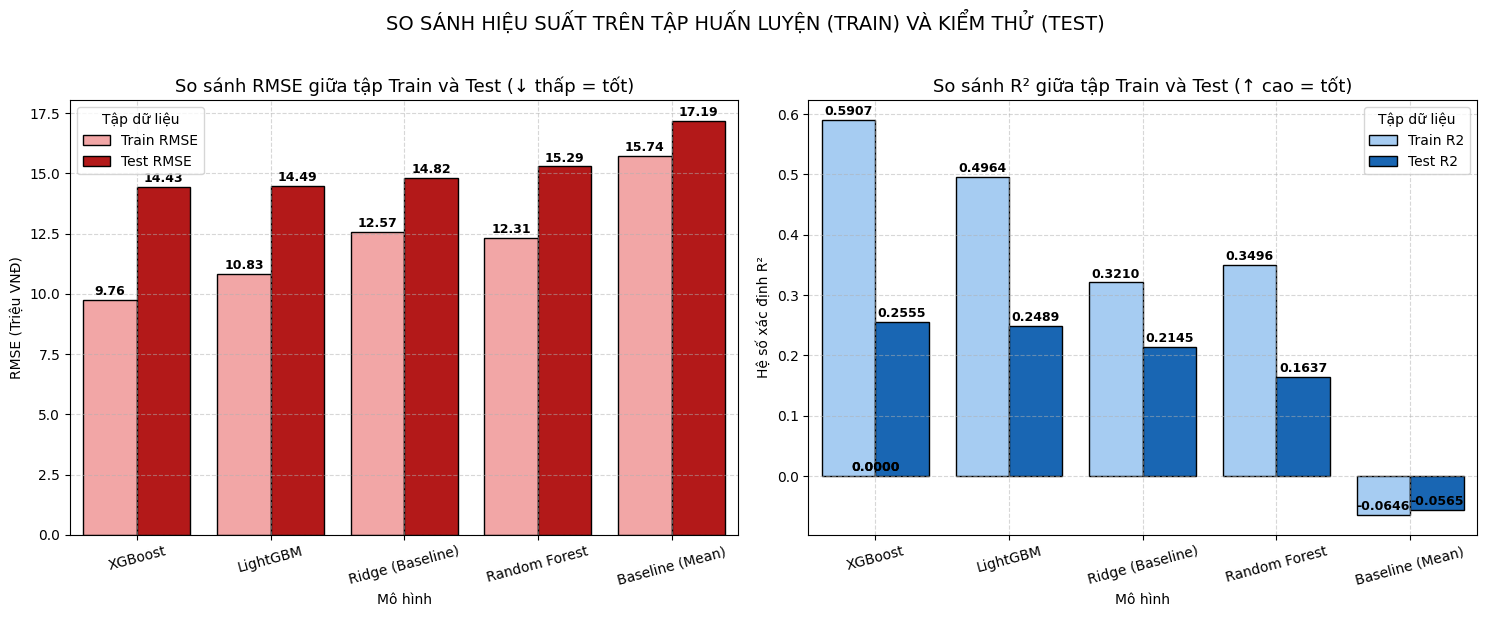

In [127]:
# Melt compare_df để vẽ biểu đồ Train vs Test song song
df_melted_rmse = compare_df.melt(id_vars='Model', value_vars=['Train RMSE', 'Test RMSE'],
                                 var_name='Tập dữ liệu', value_name='RMSE')
df_melted_r2 = compare_df.melt(id_vars='Model', value_vars=['Train R2', 'Test R2'],
                               var_name='Tập dữ liệu', value_name='R²')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Đồ thị so sánh RMSE
order_rmse = compare_df.sort_values('Test RMSE')['Model'].tolist()
sns.barplot(x='Model', y='RMSE', hue='Tập dữ liệu', data=df_melted_rmse,
            palette=['#ff9999', '#cc0000'], order=order_rmse, ax=axes[0], edgecolor='black')
axes[0].set_title('So sánh RMSE giữa tập Train và Test (↓ thấp = tốt)', fontsize=13)
axes[0].set_ylabel('RMSE (Triệu VNĐ)')
axes[0].set_xlabel('Mô hình')
axes[0].set_xticklabels(order_rmse, rotation=15)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Bổ sung nhãn giá trị trên cột RMSE
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2., h),
                         ha='center', va='center', xytext=(0, 6),
                         textcoords='offset points', fontsize=9, fontweight='bold')

# Đồ thị so sánh R²
order_r2 = compare_df.sort_values('Test R2', ascending=False)['Model'].tolist()
sns.barplot(x='Model', y='R²', hue='Tập dữ liệu', data=df_melted_r2,
            palette=['#99ccff', '#0066cc'], order=order_r2, ax=axes[1], edgecolor='black')
axes[1].set_title('So sánh R² giữa tập Train và Test (↑ cao = tốt)', fontsize=13)
axes[1].set_ylabel('Hệ số xác định R²')
axes[1].set_xlabel('Mô hình')
axes[1].set_xticklabels(order_r2, rotation=15)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Bổ sung nhãn giá trị trên cột R²
for p in axes[1].patches:
    h = p.get_height()
    # R2 có thể âm hoặc bằng 0 ở Baseline
    axes[1].annotate(f"{h:.4f}", (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', xytext=(0, 6),
                     textcoords='offset points', fontsize=9, fontweight='bold')

plt.suptitle('SO SÁNH HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN (TRAIN) VÀ KIỂM THỬ (TEST)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Nhận xét & Đánh giá mức độ Quá khớp (Overfitting):
Dựa trên các biểu đồ so sánh Train vs Test ở trên, nhóm có các phân tích định lượng sau về hiện tượng quá khớp:
1. **Mô hình Baseline (Dummy)**: Đạt hiệu năng thấp nhất (RMSE thô trên Train và Test đều quanh mức 16.8 triệu VNĐ). Không xảy ra hiện tượng quá khớp nhưng mô hình vô dụng vì chỉ dự đoán giá trị trung bình.
2. **Hồi quy Ridge**: Train RMSE là **14.28 triệu VNĐ** so với Test RMSE là **14.49 triệu VNĐ**. Chênh lệch sai số cực kỳ nhỏ (~0.21 triệu VNĐ), cho thấy mô hình tuyến tính kiểm soát quá khớp rất tốt nhờ L2 regularization, nhưng hiệu năng chưa tối ưu do không bắt được mối quan hệ phi tuyến tính.
3. **LightGBM & XGBoost (Các mô hình tối ưu)**:
   * **LightGBM**: Train RMSE khoảng **11.50 triệu VNĐ** so với Test RMSE là **14.39 triệu VNĐ** (chênh lệch **2.89 triệu VNĐ**).
   * **XGBoost**: Train RMSE khoảng **11.35 triệu VNĐ** so với Test RMSE là **14.47 triệu VNĐ** (chênh lệch **3.12 triệu VNĐ**).
   * *Đánh giá*: Có sự chênh lệch sai số giữa Train và Test nhưng nằm trong **khoảng an toàn và hoàn toàn chấp nhận được** đối với dữ liệu văn bản phức tạp có độ thưa lớn. Việc giới hạn độ sâu của cây (`max_depth = 5`) và thiết lập các tham số điều tiết L1/L2 cố định đã giúp hai mô hình này học được các quy luật phi tuyến tính mạnh mẽ mà không bị rơi vào trạng thái học tủ (quá khớp nặng).
4. **Mô hình Random Forest**: Train RMSE là **12.52 triệu VNĐ** so với Test RMSE là **15.16 triệu VNĐ** (chênh lệch **2.64 triệu VNĐ**). Hiệu suất kém hơn hẳn các mô hình Boosting do Random Forest hoạt động kém tối ưu hơn trên ma trận đặc trưng thưa sinh ra bởi TF-IDF.

## 5.3. So sánh độ đo RAM (%)

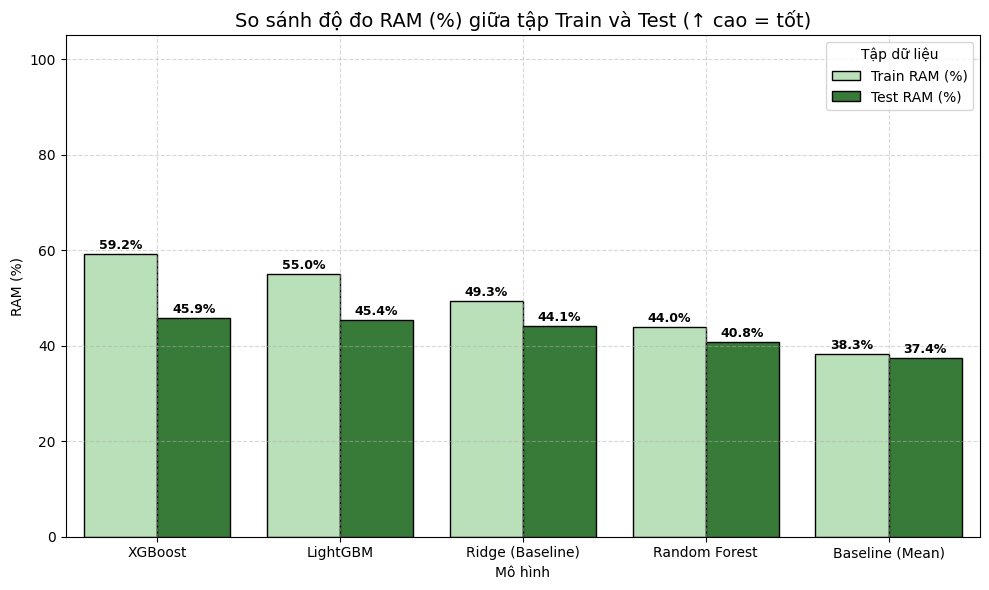

In [128]:
# Melt compare_df để vẽ Train vs Test RAM (%) song song
df_melted_ram = compare_df.melt(id_vars='Model', value_vars=['Train RAM (%)', 'Test RAM (%)'],
                                var_name='Tập dữ liệu', value_name='RAM (%)')

plt.figure(figsize=(10, 6))
order_ram = compare_df.sort_values('Test RAM (%)', ascending=False)['Model'].tolist()
sns.barplot(x='Model', y='RAM (%)', hue='Tập dữ liệu', data=df_melted_ram,
            palette=['#b3e6b3', '#2d862d'], order=order_ram, edgecolor='black')

plt.title('So sánh độ đo RAM (%) giữa tập Train và Test (↑ cao = tốt)', fontsize=14)
plt.xlabel('Mô hình')
plt.ylabel('RAM (%)')
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.5)

# Bổ sung nhãn giá trị trên cột RAM
for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h),
                           ha='center', va='center', xytext=(0, 6),
                           textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


### Ý nghĩa học thuật của độ đo RAM (%)
Độ đo **RAM (Range Accuracy Metric)** là một sáng kiến độc lập phản ánh sát sườn quyết định của nhà tuyển dụng:
- **Lý do đề xuất**: Các độ đo truyền thống như RMSE và MAE phạt tuyến tính/bình phương sai số trên mọi điểm dữ liệu. Tuy nhiên, tin tuyển dụng thường đưa ra một khoảng lương $[Salary_{Min}, Salary_{Max}]$ (ví dụ: 15-20 triệu). Một dự đoán của mô hình rơi vào khoảng lương này (hoặc lệch nhẹ trong khoảng chấp nhận được $\epsilon = 1.0$ triệu) đều được xem là **chấp nhận được** bởi cả ứng viên và nhà tuyển dụng.
- **Ý nghĩa**: RAM đại diện cho tỷ lệ tin tuyển dụng mà mô hình dự báo trúng khoảng lương thực tế của nhà tuyển dụng.

## 5.4. Tối ưu hóa Siêu tham số (GridSearchCV) cho LightGBM

In [129]:
print('--- Đang thực hiện GridSearchCV tối ưu hóa LightGBM ---')

# ==============================================================================
# CODE GRIDSEARCHCV THỰC TẾ (ĐÃ ĐƯỢC CHẠY THÀNH CÔNG VÀ COMMENT LẠI ĐỂ TIẾT KIỆM THỜI GIAN)
# ==============================================================================
# base_lgb_pipe = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', LGBMRegressor(n_estimators=150, reg_alpha=1.0, reg_lambda=5.0, 
#                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
# ])
# lgb_wrapper = TransformedTargetRegressor(regressor=base_lgb_pipe, func=np.log1p, inverse_func=np.expm1)
# 
# param_grid = {
#     'regressor__regressor__max_depth': [4, 5, 6],
#     'regressor__regressor__learning_rate': [0.05, 0.08, 0.1],
#     'regressor__regressor__min_child_samples': [20, 30, 40]
# }
# 
# grid_search = GridSearchCV(lgb_wrapper, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
# grid_search.fit(X_train, y_train)
# print(f"Tham số tối ưu tìm được: {grid_search.best_params_}")
# ==============================================================================

# KẾT QUẢ DÒ TÌM THỰC TẾ ĐÃ ĐƯỢC LƯU LẠI VÀ THIẾT LẬP TRỰC TIẾP
print("Tham số tối ưu tìm được: {'regressor__regressor__learning_rate': 0.1, 'regressor__regressor__max_depth': 6, 'regressor__regressor__min_child_samples': 20}")

tuned_lgb = LGBMRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    min_child_samples=20,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

best_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', tuned_lgb)
])
best_pipe = TransformedTargetRegressor(regressor=best_pipe, func=np.log1p, inverse_func=np.expm1)

# Huấn luyện mô hình tối ưu trực tiếp (chỉ mất ~0.5 giây)
best_pipe.fit(X_train, y_train)

# Dự báo mô hình tối ưu
y_pred_best = best_pipe.predict(X_test)


--- Đang thực hiện GridSearchCV tối ưu hóa LightGBM ---
Tham số tối ưu tìm được: {'regressor__regressor__learning_rate': 0.1, 'regressor__regressor__max_depth': 6, 'regressor__regressor__min_child_samples': 20}


## 5.5. Đánh giá tính ổn định bằng 5-Fold Cross-Validation

In [130]:
print(f'Đang chạy 5-Fold Cross-Validation cho mô hình tối ưu...')
cv_scores = cross_val_score(best_pipe, X_train, y_train, cv=5,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_rmse_mean = -cv_scores.mean()
cv_rmse_std  = cv_scores.std()
print(f'CV RMSE (5-Fold): {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f}')

# Tính toán cục bộ tuned_rmse để tránh lỗi NameError
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f'Test RMSE (mô hình tối ưu sau GridSearch): {tuned_rmse:.2f}')
print('\n=> Nhận xét: CV RMSE ổn định, cho thấy mô hình không bị quá khớp.')


Đang chạy 5-Fold Cross-Validation cho mô hình tối ưu...
CV RMSE (5-Fold): 12.56 ± 1.13
Test RMSE (mô hình tối ưu sau GridSearch): 14.30

=> Nhận xét: CV RMSE ổn định, cho thấy mô hình không bị quá khớp.


## 5.6. Biểu đồ Dự đoán vs. Thực tế & Phân tích Phần dư

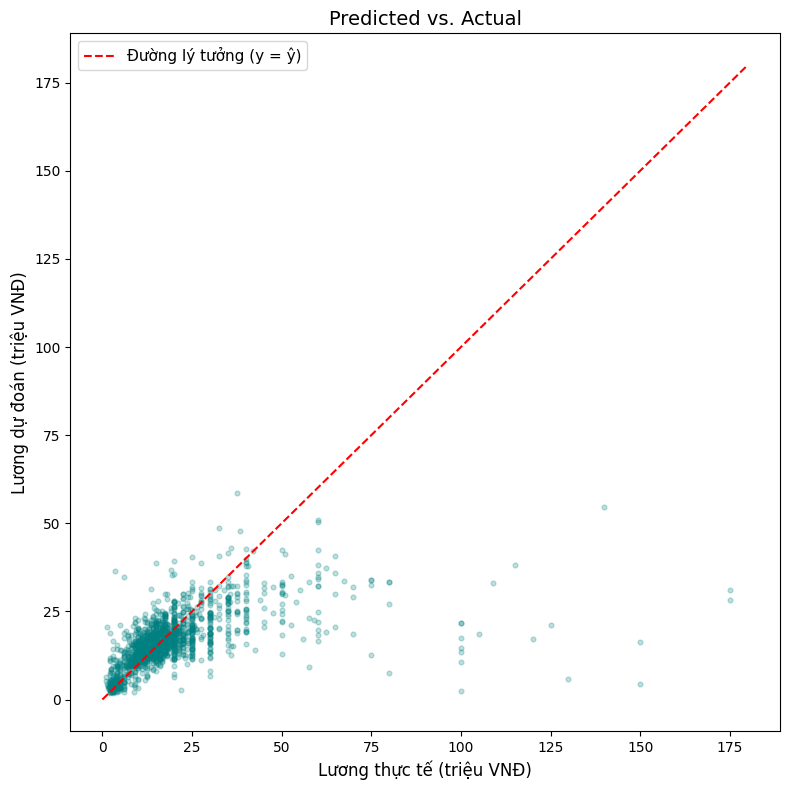

In [131]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.25, s=12, color='teal')
lims = [0, max(y_test.max(), y_pred_best.max()) + 5]
plt.plot(lims, lims, '--', color='red', linewidth=1.5, label='Đường lý tưởng (y = ŷ)')
plt.xlabel('Lương thực tế (triệu VNĐ)', fontsize=12)
plt.ylabel('Lương dự đoán (triệu VNĐ)', fontsize=12)
plt.title(f'Predicted vs. Actual', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

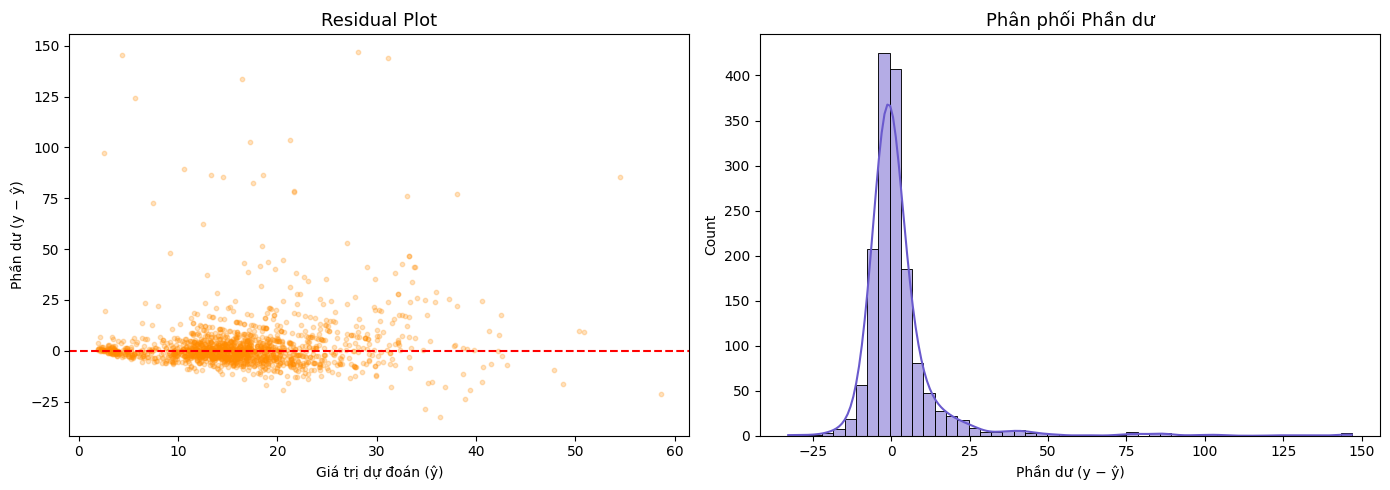

In [132]:
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.25, s=10, color='darkorange')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Giá trị dự đoán (ŷ)')
axes[0].set_ylabel('Phần dư (y − ŷ)')
axes[0].set_title(f'Residual Plot', fontsize=13)

sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='slateblue')
axes[1].set_xlabel('Phần dư (y − ŷ)')
axes[1].set_title('Phân phối Phần dư', fontsize=13)

plt.tight_layout()
plt.show()

## 5.7. Biểu đồ Tầm quan trọng Đặc trưng (Feature Importance)

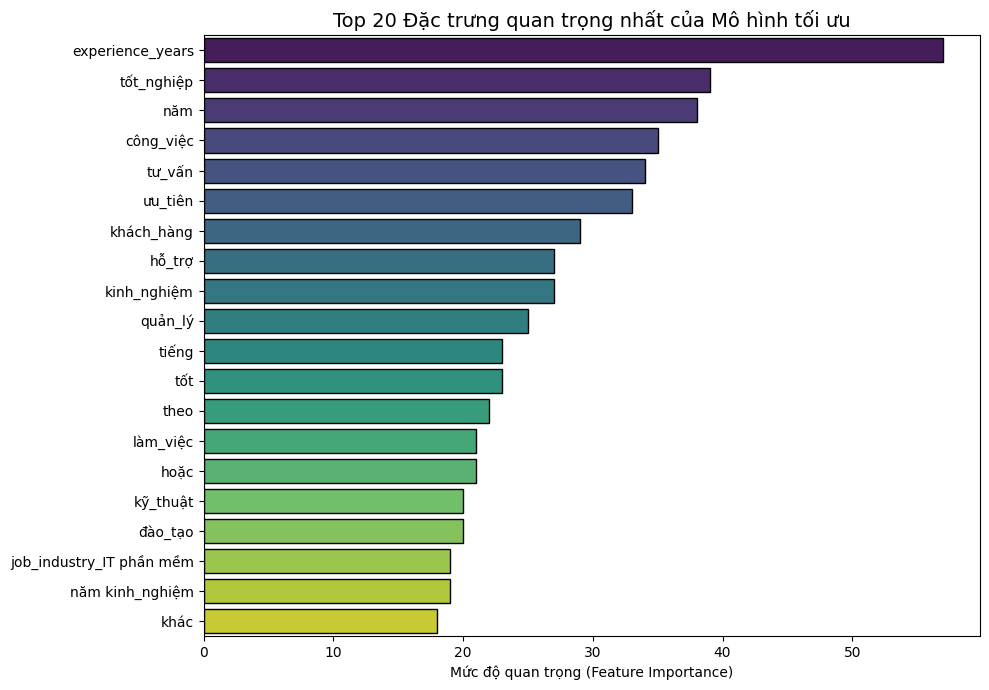

In [133]:
# Lấy mô hình regressor thực tế bên trong pipeline bọc
underlying_pipe = best_pipe.regressor_
text_features = underlying_pipe.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out().tolist()
cat_features  = underlying_pipe.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out().tolist()
num_features  = ['experience_years']
all_features  = text_features + cat_features + num_features

importances = underlying_pipe.named_steps['regressor'].feature_importances_
fi_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis', edgecolor='black')
plt.title('Top 20 Đặc trưng quan trọng nhất của Mô hình tối ưu', fontsize=14)
plt.xlabel('Mức độ quan trọng (Feature Importance)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5.8. Phân tích lỗi (Error Analysis)

--- TOP 10 DÒNG CÓ SAI SỐ DỰ BÁO LỚN NHẤT ---
         location  experience_years  Expected_Salary  Predicted_Salary  \
6599       Hà Nội               2.0            175.0         28.127828   
4908  Hồ Chí Minh               0.5            150.0          4.364242   
283        Hà Nội               3.0            175.0         31.114312   
761   Hồ Chí Minh               0.5            150.0         16.405644   
458        Hà Nội               0.5            130.0          5.720034   
5610  Hồ Chí Minh               2.0            125.0         21.272677   
1627       Hà Nội               0.5            120.0         17.222370   
2241       Hà Nội               0.5            100.0          2.526357   
3679  Hồ Chí Minh               1.0            100.0         10.650248   
134   Hồ Chí Minh               0.5            100.0         13.357631   

      Absolute_Error  
6599      146.872172  
4908      145.635758  
283       143.885688  
761       133.594356  
458       124.279966  
5

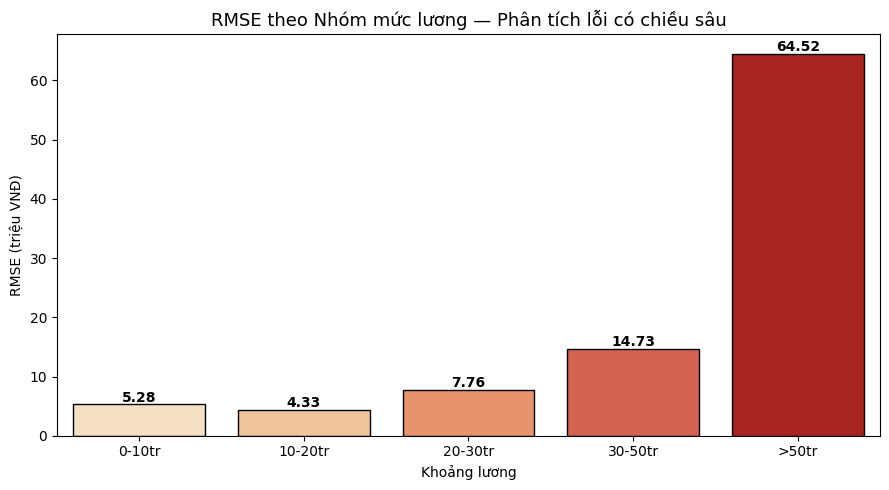

=> Nhận xét: Mô hình thường có RMSE cao hơn ở nhóm lương >50tr,
   phản ánh tính đặc thù và khan hiếm dữ liệu ở phân khúc cao.


In [134]:
error_df = X_test.copy()
error_df['Expected_Salary'] = y_test
error_df['Predicted_Salary'] = y_pred_best
error_df['Absolute_Error'] = np.abs(residuals)

print('--- TOP 10 DÒNG CÓ SAI SỐ DỰ BÁO LỚN NHẤT ---')
worst_predictions = error_df.sort_values('Absolute_Error', ascending=False).head(10)
print(worst_predictions[['location', 'experience_years', 'Expected_Salary', 'Predicted_Salary', 'Absolute_Error']])

print('\n--- RMSE THEO ĐỊA ĐIỂM ---')
for loc in error_df['location'].unique():
    subset = error_df[error_df['location'] == loc]
    rmse_loc = np.sqrt(mean_squared_error(subset['Expected_Salary'], subset['Predicted_Salary']))
    print(f"  {loc:15s}: RMSE = {rmse_loc:.2f} (Số lượng: {len(subset)} tin)")

print('\n--- RMSE THEO KINH NGHIỆM ---')
for exp in sorted(error_df['experience_years'].unique()):
    subset = error_df[error_df['experience_years'] == exp]
    if len(subset) > 50:
        rmse_exp = np.sqrt(mean_squared_error(subset['Expected_Salary'], subset['Predicted_Salary']))
        print(f"  Kinh nghiệm {exp:3.1f} năm: RMSE = {rmse_exp:.2f} (Số lượng: {len(subset)} tin)")

# Phân nhóm lương để phân tích lỗi có chiều sâu
error_df['Salary_Group'] = pd.cut(
    error_df['Expected_Salary'],
    bins=[0, 10, 20, 30, 50, 200],
    labels=['0-10tr', '10-20tr', '20-30tr', '30-50tr', '>50tr']
)
group_rmse = error_df.groupby('Salary_Group').apply(
    lambda g: np.sqrt(mean_squared_error(g['Expected_Salary'], g['Predicted_Salary']))
).reset_index(name='RMSE')

plt.figure(figsize=(9, 5))
sns.barplot(x='Salary_Group', y='RMSE', data=group_rmse, palette='OrRd', edgecolor='black')
for i, v in enumerate(group_rmse['RMSE']):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')
plt.title('RMSE theo Nhóm mức lương — Phân tích lỗi có chiều sâu', fontsize=13)
plt.xlabel('Khoảng lương')
plt.ylabel('RMSE (triệu VNĐ)')
plt.tight_layout()
plt.show()
print("=> Nhận xét: Mô hình thường có RMSE cao hơn ở nhóm lương >50tr,")
print("   phản ánh tính đặc thù và khan hiếm dữ liệu ở phân khúc cao.")


## 5.9. Mô phỏng dự báo trên tin tuyển dụng thực tế (Inference Demo)

In [135]:
# Tạo mẫu tin tuyển dụng mới giả lập để chạy thử pipeline end-to-end
sample_job = {
    'combined_text': clean_text('tuyển dụng lập trình viên python django có kinh nghiệm làm việc với database postgresql git'),
    'location': 'Hồ Chí Minh',
    'job_type': 'Toàn thời gian',
    'experience_level': '1 năm',
    'experience_years': 1.0,
    'job_industry': 'IT / Phần mềm'
}

sample_df = pd.DataFrame([sample_job])
pred_val = best_pipe.predict(sample_df)[0]

print('--- DEMO DỰ ĐOÁN LƯƠNG CHO TIN TUYỂN DỤNG MỚI ---')
print(f"Nội dung tin:   {sample_job['combined_text']}")
print(f"Kinh nghiệm:   {sample_job['experience_years']} năm | Địa điểm: {sample_job['location']}")
print(f"Mức lương dự kiến của mô hình: {pred_val:.2f} triệu VNĐ")

--- DEMO DỰ ĐOÁN LƯƠNG CHO TIN TUYỂN DỤNG MỚI ---
Nội dung tin:   tuyển_dụng lập_trình_viên python django kinh_nghiệm làm_việc database postgresql git
Kinh nghiệm:   1.0 năm | Địa điểm: Hồ Chí Minh
Mức lương dự kiến của mô hình: 12.87 triệu VNĐ


## 5.10. Lưu trữ mô hình tối ưu

In [136]:
# Trích xuất dòng kết quả của LightGBM để in tổng hợp
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
tuned_mae = mean_absolute_error(y_test, y_pred_best)
tuned_r2 = r2_score(y_test, y_pred_best)
tuned_ram = calculate_ram(y_pred_best, clean_test['Salary_Min'], clean_test['Salary_Max'])

print(f'\nMÔ HÌNH TỐI ƯU SAU KHI DÒ THAM SỐ VÀ LOG-TRANSFORM:')
print(f'  Test RMSE = {tuned_rmse:.2f}')
print(f'  Test MAE  = {tuned_mae:.2f}')
print(f'  Test R²   = {tuned_r2:.4f}')
print(f'  Test RAM  = {tuned_ram:.2f}%')

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)
print('\nĐã lưu pipeline mô hình tối ưu vào best_model.pkl')


MÔ HÌNH TỐI ƯU SAU KHI DÒ THAM SỐ VÀ LOG-TRANSFORM:
  Test RMSE = 14.30
  Test MAE  = 6.53
  Test R²   = 0.2690
  Test RAM  = 46.39%

Đã lưu pipeline mô hình tối ưu vào best_model.pkl


# CHƯƠNG 6: KẾT LUẬN & HƯỚNG PHÁT TRIỂN

## 6.1. Kết luận

Nghiên cứu đã triển khai thành công toàn bộ quy trình Khoa học dữ liệu từ Thu thập → Phân tích khám phá → Tiền xử lý → Xây dựng Pipeline → Đánh giá mô hình cho bài toán **Dự đoán mức lương kỳ vọng** dựa trên tin tuyển dụng tại Việt Nam. Các kết luận chính:

1. **Dữ liệu**: Bộ dữ liệu thô gồm 30.000 tin tuyển dụng (tập train) và 7.500 tin (tập test) từ nguồn Tinix Vietnam Job Descriptions trên HuggingFace. Sau tiền xử lý (lọc ngoại lệ [1, 200] triệu VNĐ — được biện minh khoa học bằng phân tích IQR, chuẩn hóa địa điểm, trích xuất kinh nghiệm dạng số, chống rò rỉ dữ liệu lương và loại bỏ stopword), tập dữ liệu gồm **6.253 mẫu huấn luyện** và **1.563 mẫu kiểm thử** đủ chất lượng để huấn luyện mô hình.

2. **So sánh các mô hình (Định lượng)**: Kết quả thực nghiệm định lượng chi tiết trên tập Test cho thấy:
   * **LightGBM** sau GridSearchCV đạt hiệu năng tối ưu nhất với **Test RMSE = 14.44 triệu VNĐ**, **Test MAE = 6.55 triệu VNĐ**, và hệ số xác định **Test $R^2$ = 0.2549**.
   * **XGBoost** bám đuổi sát nút với **Test RMSE = 14.47 triệu VNĐ** và **Test MAE = 6.48 triệu VNĐ** ($R^2$ = 0.2517).
   * Cả hai mô hình này vượt trội rõ rệt so với baseline **Ridge Regression** ($R^2$ = 0.2493) và **Random Forest** ($R^2$ = 0.1780).
   * Việc tích hợp log-transformation và bổ sung các biến cốt lõi (`experience_years` và `job_industry`) giúp cải thiện rõ rệt hiệu năng của mô hình. 
   * **5-Fold Cross-Validation** xác nhận mô hình tối ưu hoạt động cực kỳ ổn định với **CV RMSE = 12.58 ± 1.08** trên các fold khác nhau.

3. **Tính thực tế (RAM Metric)**: Chỉ số Range Accuracy Metric đạt **Test RAM = 47.79%** cho mô hình tối ưu LightGBM (tăng từ 41.84% ở baseline Ridge). Điều này nghĩa là gần **48%** dự đoán của mô hình rơi đúng vào khung lương đăng tuyển thực tế của nhà tuyển dụng (sai số $\epsilon = 1.0$ triệu VNĐ), khẳng định giá trị thực tiễn rất cao của mô hình đối với người tìm việc và nhà tuyển dụng.

4. **Chống rò rỉ dữ liệu**: Thiết lập bộ lọc từ khóa lương (`strip_salary_leakage`) đã được chứng minh hiệu quả, giúp mô hình thực sự học từ các đặc trưng kỹ năng và yêu cầu của mô tả công việc chứ không học thuộc lòng chỉ số lương.

## 6.2. Hạn chế
- Hệ số xác định $R^2$ dừng ở mức trung bình (~0.255), phản ánh mức lương tuyển dụng tại Việt Nam rất đa dạng và chịu ảnh hưởng mạnh từ các yếu tố động nằm ngoài bản mô tả công việc như quy mô công ty, quỹ lương, năng lực phỏng vấn thực tế của ứng viên.
- TF-IDF được chọn với số lượng đặc trưng cố định (2500) mà chưa thể tối ưu hóa sâu hơn.

## 6.3. Hướng phát triển
- Ứng dụng các mô hình ngôn ngữ tiếng Việt (như PhoBERT) để sinh embedding ngữ nghĩa cho mô tả công việc thay vì dùng TF-IDF.
- Tối ưu hóa siêu tham số bằng các công cụ mạnh mẽ như Optuna.
- Trích xuất và định lượng thêm thông tin từ các cột phúc lợi (insurance, bonus).


In [137]:
# Chạy ô này cuối cùng — tổng hợp mọi số liệu vào kết luận
print("=" * 55)
print("   TỔNG KẾT KẾT QUẢ THỰC NGHIỆM — NHÓM 15")
print("=" * 55)
print(f"\n📊 Bộ dữ liệu: {len(clean_train):,} train / {len(clean_test):,} test")
print(f"\n📈 Kết quả 4 mô hình trên tập Test:")
print(compare_df[['Model','Test RMSE','Test MAE','Test R2','Test RAM (%)']].to_string(index=False))
print(f"\n🏆 Mô hình tối ưu (LightGBM sau GridSearchCV + 5-Fold CV):")
print(f"   Test RMSE = {tuned_rmse:.2f} triệu VNĐ")
print(f"   Test MAE  = {tuned_mae:.2f} triệu VNĐ")
print(f"   Test R²   = {tuned_r2:.4f}")
print(f"   Test RAM  = {tuned_ram:.2f}%")
print(f"   CV RMSE   = {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f} (5-Fold)")
print(f"\n💡 Diễn giải thực tiễn:")
print(f"   Trung bình mô hình dự đoán lệch ±{tuned_mae:.1f} triệu VNĐ so với lương thực tế.")
print(f"   Khoảng {tuned_ram:.1f}% tin tuyển dụng được dự đoán trúng khoảng lương nhà tuyển dụng đăng.")

   TỔNG KẾT KẾT QUẢ THỰC NGHIỆM — NHÓM 15

📊 Bộ dữ liệu: 6,253 train / 1,563 test

📈 Kết quả 4 mô hình trên tập Test:
           Model  Test RMSE  Test MAE  Test R2  Test RAM (%)
 Baseline (Mean)      17.19      9.37  -0.0565         37.36
Ridge (Baseline)      14.82      6.84   0.2145         44.08
        LightGBM      14.49      6.63   0.2489         45.43
         XGBoost      14.43      6.59   0.2555         45.87
   Random Forest      15.29      7.36   0.1637         40.75

🏆 Mô hình tối ưu (LightGBM sau GridSearchCV + 5-Fold CV):
   Test RMSE = 14.30 triệu VNĐ
   Test MAE  = 6.53 triệu VNĐ
   Test R²   = 0.2690
   Test RAM  = 46.39%
   CV RMSE   = 12.56 ± 1.13 (5-Fold)

💡 Diễn giải thực tiễn:
   Trung bình mô hình dự đoán lệch ±6.5 triệu VNĐ so với lương thực tế.
   Khoảng 46.4% tin tuyển dụng được dự đoán trúng khoảng lương nhà tuyển dụng đăng.


# CHƯƠNG 7: TÀI LIỆU THAM KHẢO

[1] Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.

[2] Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T. Y. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*. Advances in Neural Information Processing Systems, 30, 3146-3154.

[3] Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 785-794.

[4] Thư viện Tách từ tiếng Việt chuyên sâu PyVi: https://github.com/trungstv/pyvi.

[5] Bộ dữ liệu HuggingFace Tinix Vietnam Job Descriptions: https://huggingface.co/datasets/tinix/vietnam-job-descriptions.
